# EDA - ChEBI

Źródło: https://www.ebi.ac.uk/chebi/

In [1]:
import warnings
from importlib.metadata import PackageNotFoundError, version

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Draw
from sklearn.decomposition import TruncatedSVD

from skfp.fingerprints import ECFPFingerprint, RDKit2DDescriptorsFingerprint
from skfp.preprocessing import MolFromSmilesTransformer, MolToSmilesTransformer

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
rng = np.random.default_rng(42)


def pkg_version(package_name):
    try:
        return version(package_name)
    except PackageNotFoundError:
        return "unknown"


print("Versions")
for package_name in [
    "scikit-fingerprints",
    "rdkit",
    "pandas",
    "numpy",
    "scikit-learn",
]:
    print(f"{package_name:20s} {pkg_version(package_name)}")


C:\Users\barte\PycharmProjects\MWPD_projekt\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Versions
scikit-fingerprints  2.0.0
rdkit                2025.9.3
pandas               3.0.2
numpy                2.4.4
scikit-learn         1.9.0


## 1. Wczytanie danych

In [2]:
DATA_PATH = "data/chebi_dataset_train.parquet"

df = pd.read_parquet(DATA_PATH)

object_cols = df.select_dtypes(include="object").columns.tolist()

exact_smiles = []
contains_smiles = []
for col in df.columns:
    col_lower = col.lower()
    if col_lower == "smiles":
        exact_smiles.append(col)
    if "smiles" in col_lower:
        contains_smiles.append(col)

smiles_candidates = exact_smiles.copy()
for col in contains_smiles:
    if col not in smiles_candidates:
        smiles_candidates.append(col)

smiles_col = smiles_candidates[0] if smiles_candidates else object_cols[0]

label_cols = []
for col in df.columns:
    if col == smiles_col:
        continue
    if pd.api.types.is_numeric_dtype(df[col]):
        label_cols.append(col)

id_cols = []
for col in object_cols:
    if col != smiles_col:
        id_cols.append(col)

missing_values_total = int(df.isna().sum().sum())

print(f"Shape:             {df.shape}")
print(f"SMILES column:     {smiles_col!r}")
print(f"ID/text columns:   {id_cols}")
print(f"Label columns:     {len(label_cols)}")
print(f"Missing values:    {missing_values_total:,}")
display(df.head(3))


Shape:             (33668, 502)
SMILES column:     'SMILES'
ID/text columns:   ['mol_id']
Label columns:     500
Missing values:    0


,mol_id,SMILES,class_0,class_1,class_2,class_3,class_4,class_5,class_6,class_7,...,class_490,class_491,class_492,class_493,class_494,class_495,class_496,class_497,class_498,class_499
0,mol_12500,CCCCC/C=C\CCCCCCCC(=O)O,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,mol_15962,Cc1cc2cc(O)cc(O)c2c(C)n1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,mol_42147,C[C@H](CCC[C@@H](C)C=O)[C@H]1CC[C@H]2[C@@H]3CC...,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


## 2. Walidacje struktury danych i etykiet

,check,status,value
0,SMILES column detected,OK,SMILES
1,At least one label column,OK,500
2,Unique column names,OK,0
3,Non-empty dataset,OK,33668
4,Labels are binary,OK,[]
5,No missing label values,OK,0
6,Rows without labels,OK,0
7,Constant label columns,WARN,1


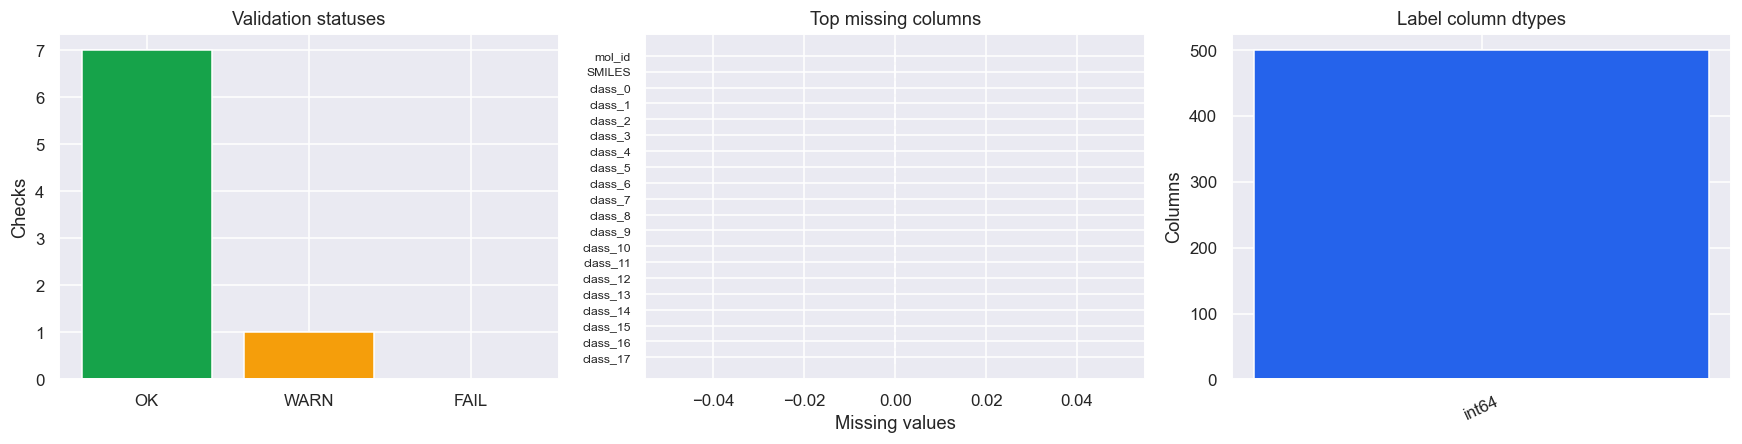

In [3]:
validation_rows = []

validation_rows.append(
    {
        "check": "SMILES column detected",
        "status": "OK" if smiles_col in df.columns else "FAIL",
        "value": smiles_col,
    }
)
validation_rows.append(
    {
        "check": "At least one label column",
        "status": "OK" if len(label_cols) > 0 else "FAIL",
        "value": len(label_cols),
    }
)
validation_rows.append(
    {
        "check": "Unique column names",
        "status": "OK" if df.columns.is_unique else "FAIL",
        "value": int(df.columns.duplicated().sum()),
    }
)
validation_rows.append(
    {
        "check": "Non-empty dataset",
        "status": "OK" if len(df) > 0 else "FAIL",
        "value": len(df),
    }
)

label_values = (
    pd.Series(df[label_cols].to_numpy().ravel())
    if label_cols
    else pd.Series(dtype=float)
)
unexpected_label_values = sorted(
    set(label_values.dropna().unique()).difference({0, 1, 0.0, 1.0})
)
label_missing = int(df[label_cols].isna().sum().sum()) if label_cols else 0
empty_label_rows_raw = int((df[label_cols].sum(axis=1) == 0).sum()) if label_cols else 0
constant_label_cols = []
for col in label_cols:
    if df[col].nunique(dropna=False) <= 1:
        constant_label_cols.append(col)

validation_rows.extend(
    [
        {
            "check": "Labels are binary",
            "status": "OK" if len(unexpected_label_values) == 0 else "WARN",
            "value": unexpected_label_values[:10],
        },
        {
            "check": "No missing label values",
            "status": "OK" if label_missing == 0 else "WARN",
            "value": label_missing,
        },
        {
            "check": "Rows without labels",
            "status": "OK" if empty_label_rows_raw == 0 else "WARN",
            "value": empty_label_rows_raw,
        },
        {
            "check": "Constant label columns",
            "status": "OK" if len(constant_label_cols) == 0 else "WARN",
            "value": len(constant_label_cols),
        },
    ]
)

schema_validation = pd.DataFrame(validation_rows)
display(schema_validation)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

status_counts = schema_validation["status"].value_counts().reindex(["OK", "WARN", "FAIL"], fill_value=0)
axes[0].bar(status_counts.index, status_counts.values, color=["#16a34a", "#f59e0b", "#dc2626"])
axes[0].set_title("Validation statuses")
axes[0].set_ylabel("Checks")

missing_by_col = df.isna().sum().sort_values(ascending=False)
top_missing = missing_by_col.head(20)
axes[1].barh(range(len(top_missing)), top_missing.values, color="#64748b")
axes[1].set_yticks(range(len(top_missing)))
axes[1].set_yticklabels(top_missing.index, fontsize=8)
axes[1].invert_yaxis()
axes[1].set_title("Top missing columns")
axes[1].set_xlabel("Missing values")

label_type_counts = df[label_cols].dtypes.astype(str).value_counts() if label_cols else pd.Series(dtype=int)
axes[2].bar(label_type_counts.index.astype(str), label_type_counts.values, color="#2563eb")
axes[2].set_title("Label column dtypes")
axes[2].tick_params(axis="x", rotation=25)
axes[2].set_ylabel("Columns")

plt.tight_layout()
plt.show()


### Wnioski po walidacji struktury danych

- Dane maja poprawny uklad do klasyfikacji multilabel, jezeli kolumna SMILES zostala wykryta jednoznacznie, a etykiety sa binarne.
- Ostrzezenia w tabeli walidacyjnej nie musza oznaczac bledu, ale powinny wejsc do preprocessingu: missingi, stale klasy i rekordy bez etykiet sa szczegolnie wazne.
- W przypadku tego problemu accuracy nie bedzie dobra metryka glowna, bo wiele etykiet jest rzadkich; juz na etapie EDA trzeba patrzec na rozklad klas.

## 3. Walidacja i kanonikalizacja SMILES przez scikit-fingerpritns
Walidacja oznacza tutaj sprawdzenie, czy zapis SMILES da się poprawnie zamienić na strukturę chemiczną. Jeśli SMILES jest błędny, RDKit nie potrafi zbudować z niego cząsteczki.

Kanonikalizacja oznacza sprowadzenie różnych zapisów tej samej cząsteczki do jednej standardowej formy. Dzięki temu łatwiej wykryć duplikaty.

In [4]:
smiles_raw = df[smiles_col].astype("string")
missing_smiles = smiles_raw.isna()

mol_loader = MolFromSmilesTransformer(
    sanitize=True,
    valid_only=False,
    n_jobs=-1,
    suppress_warnings=True,
)
mols = mol_loader.transform(smiles_raw.fillna("__INVALID_SMILES__").tolist())

valid_mask_values = []
for mol, is_missing in zip(mols, missing_smiles):
    is_valid = mol is not None and not is_missing
    valid_mask_values.append(is_valid)

valid_mask = pd.Series(
    valid_mask_values,
    index=df.index,
    name="valid_smiles",
)

valid_df = df.loc[valid_mask].copy()

valid_mols = []
for mol, is_valid in zip(mols, valid_mask):
    if is_valid:
        valid_mols.append(mol)

mol_to_smiles = MolToSmilesTransformer(
    isomeric_smiles=True,
    canonical=True,
    n_jobs=-1,
    suppress_warnings=True,
)
valid_df["canonical_smiles"] = mol_to_smiles.transform(valid_mols)

valid_smiles_count = int(valid_mask.sum())
valid_smiles_pct = valid_mask.mean() * 100
invalid_count = int((~valid_mask).sum())
invalid_pct = invalid_count / len(df) * 100

print(f"All rows:           {len(df):,}")
print(f"Valid SMILES:       {valid_smiles_count:,} ({valid_smiles_pct:.2f}%)")
print(f"Invalid/missing:    {invalid_count:,} ({invalid_pct:.2f}%)")
display(valid_df[[smiles_col, "canonical_smiles"]].head(5))


All rows:           33,668
Valid SMILES:       33,668 (100.00%)
Invalid/missing:    0 (0.00%)


,SMILES,canonical_smiles
0,CCCCC/C=C\CCCCCCCC(=O)O,CCCCC/C=C\CCCCCCCC(=O)O
1,Cc1cc2cc(O)cc(O)c2c(C)n1,Cc1cc2cc(O)cc(O)c2c(C)n1
2,C[C@H](CCC[C@@H](C)C=O)[C@H]1CC[C@H]2[C@@H]3CC...,C[C@H](CCC[C@@H](C)C=O)[C@H]1CC[C@H]2[C@@H]3CC...
3,CCN=C1C=CC(=C(c2ccc(NCC)cc2)c2ccc(NCC)c(C)c2)C=C1,CCN=C1C=CC(=C(c2ccc(NCC)cc2)c2ccc(NCC)c(C)c2)C=C1
4,C[C@H](CCC(O)=N[C@@H](Cc1c[nH]c2ccccc12)C(=O)O...,C[C@H](CCC(O)=N[C@@H](Cc1c[nH]c2ccccc12)C(=O)O...


## 4. Duplikaty po kanonikalizacji

Valid rows:             33,668
Unique molecules:       33,632
Duplicate rows:         36 (0.11%)
Duplicate groups:       33


,count
canonical_smiles,
C/C=C/CCCCCCCCC=C=CCCCC(=O)O,3
c1ccccccccccccccccc1,3
C1=CC2C=CC=CC2C=C1,3
[Y],2
[H],2
N=[C][O-],2
[La],2
[Al],2
[As]#[As],2


Rows after OR merge:    33,632


,metric,value
0,raw_rows,33668
1,valid_smiles,33668
2,invalid_or_missing_smiles,0
3,unique_canonical_smiles,33632
4,duplicate_rows,36
5,duplicate_groups,33
6,duplicate_groups_with_label_conflict,7


,canonical_smiles,rows,disagreeing_labels
2,OO,2,10
6,[P],2,9
5,[H],2,6
0,FF,2,5
4,[Be],2,5
3,P#P,2,3
1,N#N,2,2


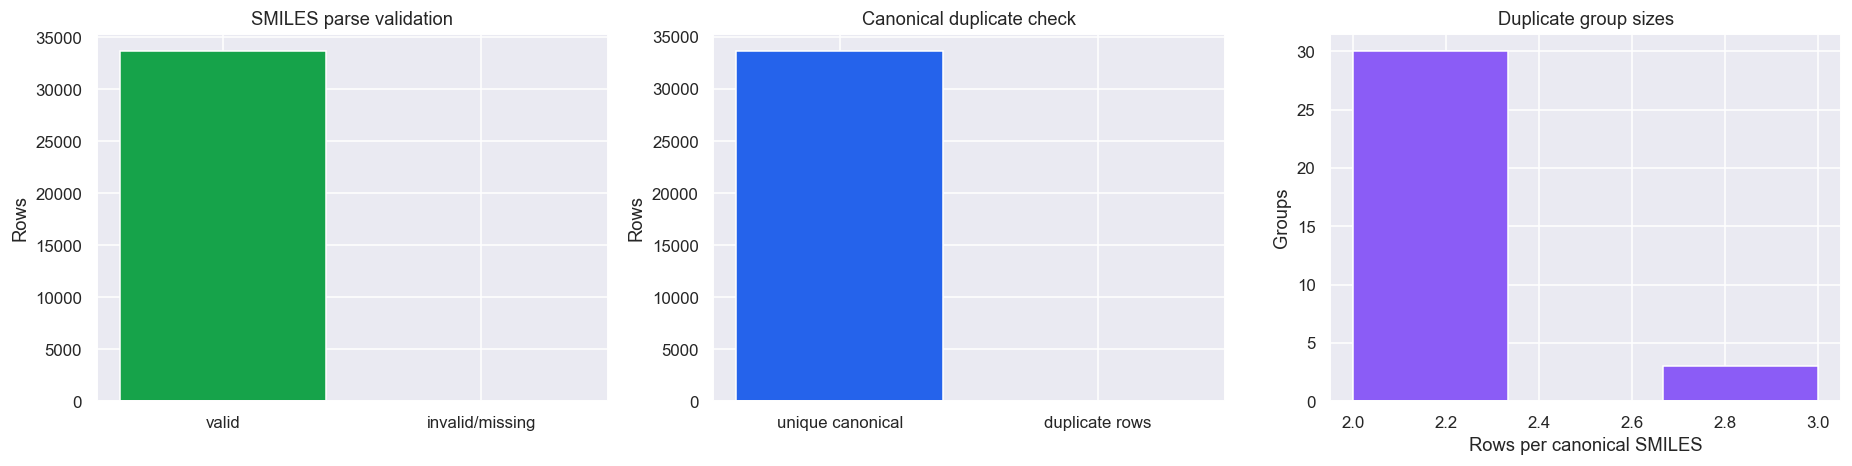

In [5]:
canon_counts = valid_df["canonical_smiles"].value_counts()
repeated = canon_counts[canon_counts > 1]
duplicate_rows = int(canon_counts.sub(1).clip(lower=0).sum())

print(f"Valid rows:             {len(valid_df):,}")
print(f"Unique molecules:       {canon_counts.size:,}")
print(f"Duplicate rows:         {duplicate_rows:,} ({duplicate_rows / len(valid_df) * 100:.2f}%)")
print(f"Duplicate groups:       {len(repeated):,}")

if len(repeated):
    display(repeated.head(10).rename("count").to_frame())

merged_label_df = valid_df.groupby("canonical_smiles")[label_cols].max()
print(f"Rows after OR merge:    {len(merged_label_df):,}")

duplicate_conflicts = []
if len(repeated):
    duplicate_df = valid_df[valid_df["canonical_smiles"].isin(repeated.index)]
    for canonical_smiles, group in duplicate_df.groupby("canonical_smiles"):
        labels = group[label_cols].to_numpy()
        disagreeing_labels = int((labels.max(axis=0) != labels.min(axis=0)).sum())
        if disagreeing_labels:
            duplicate_conflicts.append(
                {
                    "canonical_smiles": canonical_smiles,
                    "rows": len(group),
                    "disagreeing_labels": disagreeing_labels,
                }
            )

duplicate_conflicts_df = (
    pd.DataFrame(duplicate_conflicts)
    .sort_values(["disagreeing_labels", "rows"], ascending=False)
    if duplicate_conflicts
    else pd.DataFrame(columns=["canonical_smiles", "rows", "disagreeing_labels"])
)

smiles_validation = pd.DataFrame(
    [
        {"metric": "raw_rows", "value": len(df)},
        {"metric": "valid_smiles", "value": int(valid_mask.sum())},
        {"metric": "invalid_or_missing_smiles", "value": invalid_count},
        {"metric": "unique_canonical_smiles", "value": canon_counts.size},
        {"metric": "duplicate_rows", "value": duplicate_rows},
        {"metric": "duplicate_groups", "value": len(repeated)},
        {"metric": "duplicate_groups_with_label_conflict", "value": len(duplicate_conflicts_df)},
    ]
)
display(smiles_validation)

if invalid_count:
    invalid_examples = df.loc[~valid_mask, [smiles_col] + id_cols].head(10)
    display(invalid_examples)

if len(duplicate_conflicts_df):
    display(duplicate_conflicts_df.head(10))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.4))

axes[0].bar(
    ["valid", "invalid/missing"],
    [int(valid_mask.sum()), invalid_count],
    color=["#16a34a", "#dc2626"],
)
axes[0].set_title("SMILES parse validation")
axes[0].set_ylabel("Rows")

axes[1].bar(
    ["unique canonical", "duplicate rows"],
    [canon_counts.size, duplicate_rows],
    color=["#2563eb", "#f97316"],
)
axes[1].set_title("Canonical duplicate check")
axes[1].set_ylabel("Rows")

if len(repeated):
    axes[2].hist(repeated.values, bins=min(40, repeated.max()), color="#8b5cf6", edgecolor="white")
    axes[2].set_title("Duplicate group sizes")
    axes[2].set_xlabel("Rows per canonical SMILES")
    axes[2].set_ylabel("Groups")
else:
    axes[2].text(0.5, 0.5, "No duplicates", ha="center", va="center")
    axes[2].set_title("Duplicate group sizes")

plt.tight_layout()
plt.show()


**Opis:** tutaj widać, czy SMILES-y są poprawne i ile cząsteczek powtarza się po kanonikalizacji. Najważniejsze: SMILES-y przechodzą poprawnie, a duplikatów jest mało.

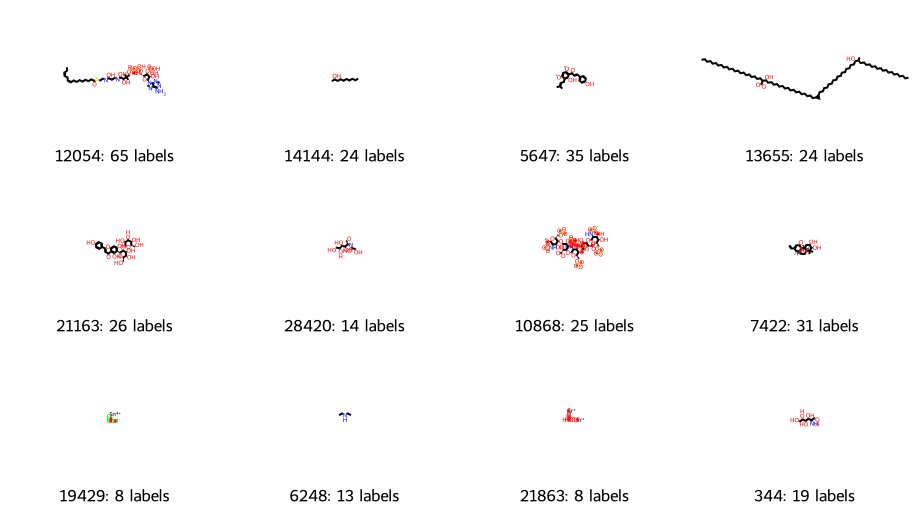

,SMILES,canonical_smiles
12054,CC/C=C\C/C=C\CCCCCCCC(=O)SCCN=C(O)CCN=C(O)[C@H...,CC/C=C\C/C=C\CCCCCCCC(=O)SCCN=C(O)CCN=C(O)[C@H...
14144,CCCCCCCCC(C)O,CCCCCCCCC(C)O
5647,COc1cc(OC)c(C(=O)/C=C/c2ccc(O)cc2)c(O)c1CC=C(C)C,COc1cc(OC)c(C(=O)/C=C/c2ccc(O)cc2)c(O)c1CC=C(C)C
13655,CCCCCCCCCCCCCCCCCCCCCCC(C(=O)[O-])C(O)CCCCCCCC...,CCCCCCCCCCCCCCCCCCCCCCC(C(=O)[O-])C(O)CCCCCCCC...
21163,O=c1cc(-c2ccc(O)cc2)oc2cc(O)c([C@@H]3O[C@H](CO...,O=c1cc(-c2ccc(O)cc2)oc2cc(O)c([C@@H]3O[C@H](CO...
28420,O=C[C@@H](N=C(O)CO)[C@@H](O)[C@H](O)[C@H](O)CO,O=C[C@@H](N=C(O)CO)[C@@H](O)[C@H](O)[C@H](O)CO
10868,CO[C@H]1O[C@H](COS(=O)(=O)[O-])[C@@H](O[C@@H]2...,CO[C@H]1O[C@H](COS(=O)(=O)[O-])[C@@H](O[C@@H]2...
7422,C=CC1=CC(=O)[C@@H]2[C@H](CC[C@@H]3C(C)(C)[C@H]...,C=CC1=CC(=O)[C@@H]2[C@H](CC[C@@H]3C(C)(C)[C@H]...
19429,[Cl-].[Cl-].[Cl-].[Cl-].[Cl-].[Cl-].[Sn+4],[Cl-].[Cl-].[Cl-].[Cl-].[Cl-].[Cl-].[Sn+4]
6248,CCNCC,CCNCC


In [6]:
sample_molecules = valid_df.sample(n=min(12, len(valid_df)), random_state=42)

sample_mols = []
sample_legends = []
for idx, row in sample_molecules.iterrows():
    mol = Chem.MolFromSmiles(row["canonical_smiles"])
    sample_mols.append(mol)

    label_count = int(valid_df.loc[idx, label_cols].sum())
    sample_legends.append(f"{idx}: {label_count} labels")

img = Draw.MolsToGridImage(
    sample_mols,
    molsPerRow=4,
    subImgSize=(230, 170),
    legends=sample_legends,
)
display(img)
display(sample_molecules[[smiles_col, "canonical_smiles"]].head(12))


**Opis:** przykładowe cząsteczki ze zbioru.

### Wnioski po walidacji SMILES i duplikatow

- Do dalszego modelowania nalezy uzywac `canonical_smiles`, bo surowy SMILES moze miec kilka zapisow dla tej samej czasteczki.
- Duplikaty najlepiej scalac po kanonikalizacji, laczac etykiety operacja OR; dzieki temu model nie dostaje tej samej struktury kilka razy z niepelna informacja.
- Jezeli tabela konfliktow etykiet w duplikatach nie jest pusta, to jest to sygnal, ze czesc rekordow ma rozne adnotacje dla tej samej czasteczki, a split train/test musi byc wykonany dopiero po scaleniu.
- Siatka struktur jest szybkim sanity checkiem chemicznym: pozwala zobaczyc, czy dane wygladaja jak realne czasteczki, a nie identyfikatory, sole zapisane nietypowo albo artefakty parsowania.

## 5. Multilabel EDA

Label cardinality:       27.5253
Label density:           0.055051
Unique labelsets:        10,066
Molecules without label: 0
Classes with 0 samples:  0
Classes with 1 sample:   0
Classes with >=100:      499


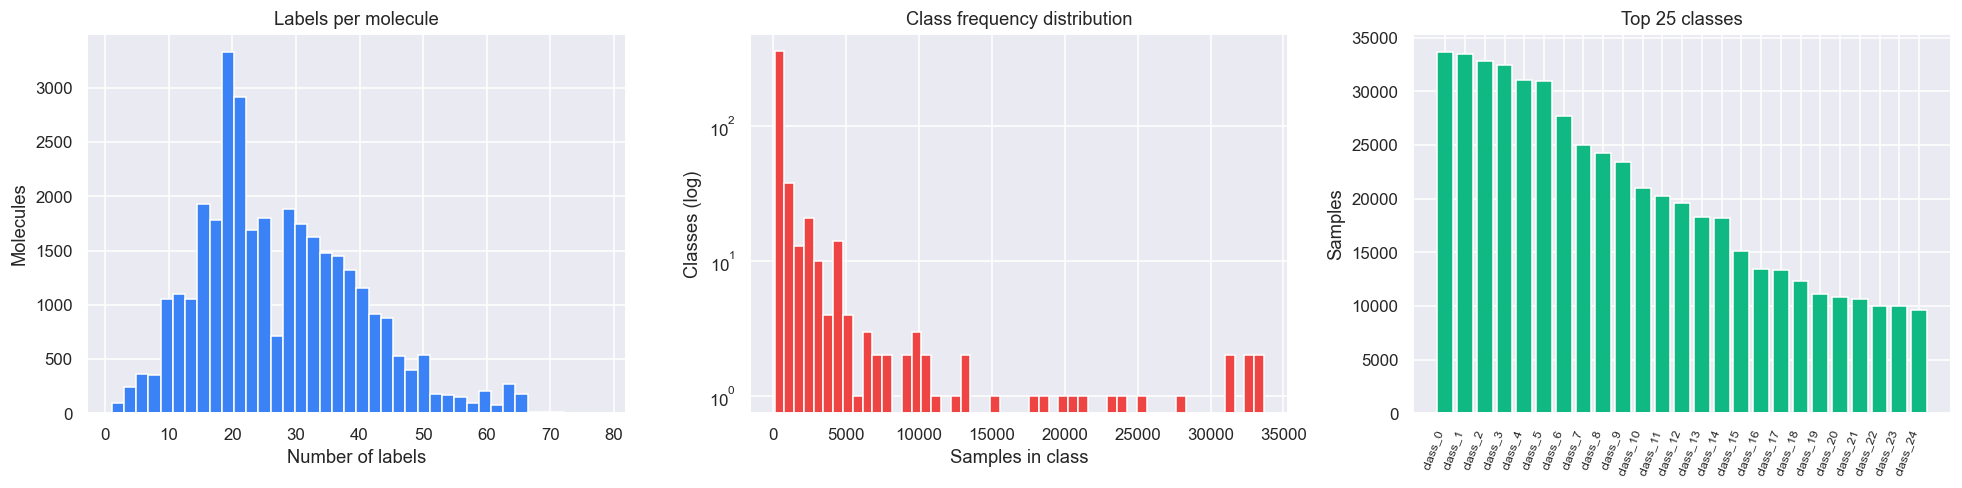

In [7]:
label_df = valid_df[label_cols].astype(np.int8)
labels_per_mol = label_df.sum(axis=1)
class_freq = label_df.sum(axis=0).sort_values(ascending=False)
freq_values = class_freq.to_numpy()

label_cardinality = labels_per_mol.mean()
label_density = label_cardinality / len(label_cols)
unique_labelsets = label_df.apply(tuple, axis=1).nunique()

molecules_without_label = int((labels_per_mol == 0).sum())
classes_with_0_samples = int((class_freq == 0).sum())
classes_with_1_sample = int((class_freq == 1).sum())
classes_with_100_or_more = int((class_freq >= 100).sum())

print(f"Label cardinality:       {label_cardinality:.4f}")
print(f"Label density:           {label_density:.6f}")
print(f"Unique labelsets:        {unique_labelsets:,}")
print(f"Molecules without label: {molecules_without_label:,}")
print(f"Classes with 0 samples:  {classes_with_0_samples:,}")
print(f"Classes with 1 sample:   {classes_with_1_sample:,}")
print(f"Classes with >=100:      {classes_with_100_or_more:,}")

fig, axes = plt.subplots(1, 3, figsize=(18, 4.6))

axes[0].hist(labels_per_mol, bins=40, color="#3b82f6", edgecolor="white")
axes[0].set_title("Labels per molecule")
axes[0].set_xlabel("Number of labels")
axes[0].set_ylabel("Molecules")

axes[1].hist(freq_values[freq_values > 0], bins=50, color="#ef4444", edgecolor="white", log=True)
axes[1].set_title("Class frequency distribution")
axes[1].set_xlabel("Samples in class")
axes[1].set_ylabel("Classes (log)")

top_n = min(25, len(class_freq))
axes[2].bar(range(top_n), class_freq.head(top_n), color="#10b981")
axes[2].set_title(f"Top {top_n} classes")
axes[2].set_ylabel("Samples")
axes[2].set_xticks(range(top_n))
axes[2].set_xticklabels(class_freq.head(top_n).index, rotation=70, ha="right", fontsize=8)

plt.tight_layout()
plt.show()


**Opis:** ten wykres pokazuje, ile etykiet mają cząsteczki i które klasy są najczęstsze. Widać, że to jest problem multilabel, bo jedna cząsteczka ma wiele klas.

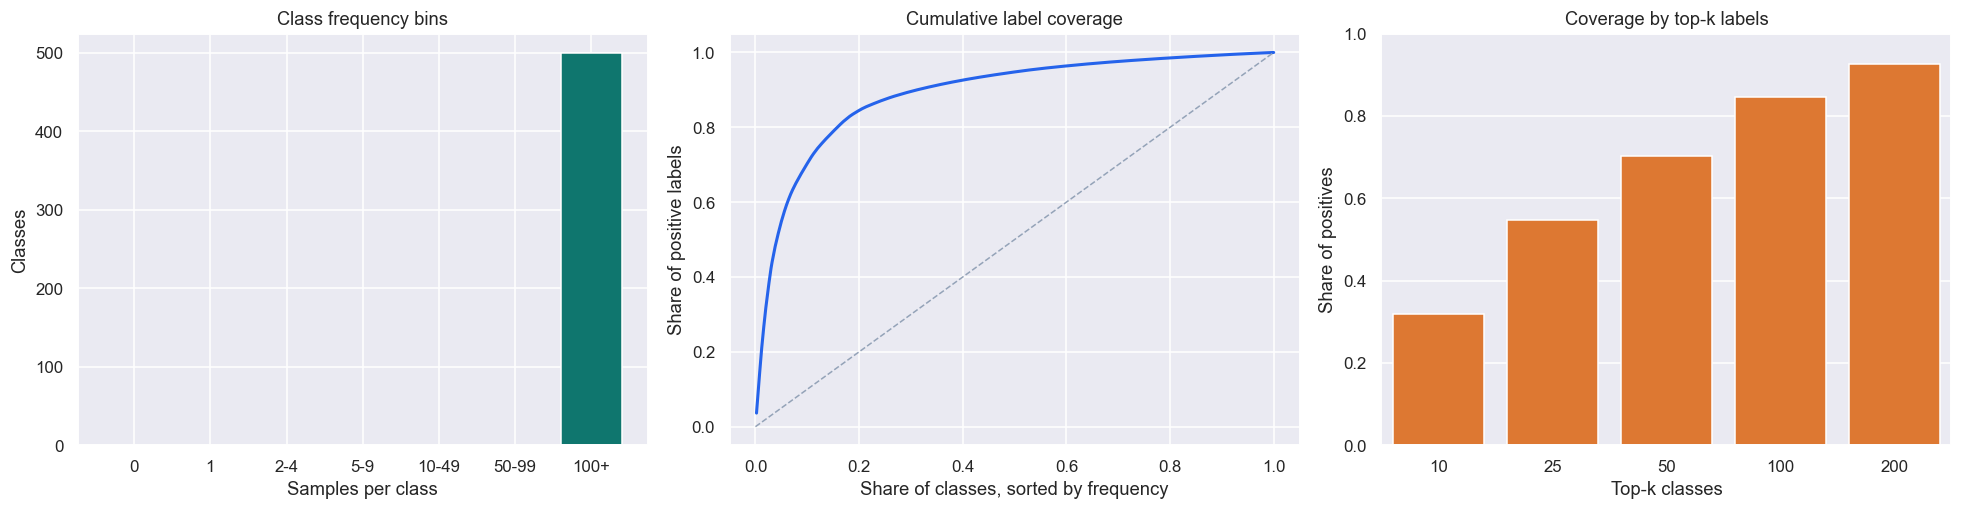

,top_k,positive_label_coverage
0,10,0.3181
1,25,0.5485
2,50,0.7035
3,100,0.8452
4,200,0.9262


In [8]:
freq_bins = pd.cut(
    class_freq,
    bins=[-0.5, 0.5, 1.5, 4.5, 9.5, 49.5, 99.5, np.inf],
    labels=["0", "1", "2-4", "5-9", "10-49", "50-99", "100+"],
)
freq_bin_counts = freq_bins.value_counts().sort_index()

sorted_freq = class_freq.sort_values(ascending=False).to_numpy()
cum_labels = np.cumsum(sorted_freq)
cum_share = cum_labels / max(cum_labels[-1], 1)
class_share = np.arange(1, len(sorted_freq) + 1) / len(sorted_freq)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

axes[0].bar(freq_bin_counts.index.astype(str), freq_bin_counts.values, color="#0f766e")
axes[0].set_title("Class frequency bins")
axes[0].set_xlabel("Samples per class")
axes[0].set_ylabel("Classes")

axes[1].plot(class_share, cum_share, color="#2563eb", linewidth=2)
axes[1].plot([0, 1], [0, 1], color="#94a3b8", linestyle="--", linewidth=1)
axes[1].set_title("Cumulative label coverage")
axes[1].set_xlabel("Share of classes, sorted by frequency")
axes[1].set_ylabel("Share of positive labels")

top_k_values = [10, 25, 50, 100, min(200, len(class_freq))]
coverage_rows = []
for k in top_k_values:
    coverage_rows.append({"top_k": k, "positive_label_coverage": class_freq.head(k).sum() / class_freq.sum()})
coverage_df = pd.DataFrame(coverage_rows)
sns.barplot(data=coverage_df, x="top_k", y="positive_label_coverage", ax=axes[2], color="#f97316")
axes[2].set_title("Coverage by top-k labels")
axes[2].set_xlabel("Top-k classes")
axes[2].set_ylabel("Share of positives")
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()
display(coverage_df.round(4))


**Opis:** tutaj najlepiej widać nierówność klas. Część klas ma dużo przykładów, ale sporo klas jest rzadszych, więc sama accuracy nie wystarczy.

### Wnioski z analizy etykiet

- Rozklad klas ma charakter long-tail: niewielka liczba klas zbiera duza czesc pozytywnych etykiet, a wiele klas ma bardzo malo przykladow.
- Przy takim rozkladzie model moze latwo nauczyc sie klas popularnych i ignorowac rzadkie, dlatego trzeba raportowac micro F1 oraz macro F1, a nie sama accuracy.
- Warto rozwazyc prog minimalnej liczby przykladow na klase, np. 5 albo 10, szczegolnie dla pierwszego stabilnego baseline'u.
- Coverage top-k pokazuje kompromis: ile informacji zostaje po ograniczeniu liczby klas i jak duzo rzadkich etykiet zostanie odrzuconych.

## 6. Deskryptory RDKit2D z scikit-fingerprints
Deskryptory są interpretowalne chemicznie. Deskryptor to liczba opisująca jakąś właściwość cząsteczki. Może to być na przykład masa cząsteczkowa, liczba pierścieni, polar surface area albo inne właściwości strukturalne.

In [9]:
rdkit2d = RDKit2DDescriptorsFingerprint(
    normalized=False,
    clip_val=1_000_000,
    n_jobs=-1,
)

X_rdkit2d = rdkit2d.transform(valid_df["canonical_smiles"].tolist())
desc_names = rdkit2d.get_feature_names_out()
desc_df = pd.DataFrame(X_rdkit2d, columns=desc_names, index=valid_df.index)
desc_df = desc_df.replace([np.inf, -np.inf], np.nan)

nan_counts = desc_df.isna().sum().sort_values(ascending=False)
desc_summary = desc_df.describe().T
desc_summary["missing"] = nan_counts

descriptors_with_nan = int((nan_counts > 0).sum())
total_nan_values = int(nan_counts.sum())

print(f"RDKit2D shape:          {desc_df.shape}")
print(f"Descriptors with NaN:   {descriptors_with_nan}")
print(f"Total NaN values:       {total_nan_values:,}")
display(desc_summary.sort_values("std", ascending=False).head(12).round(3))


RDKit2D shape:          (33668, 200)
Descriptors with NaN:   4
Total NaN values:       928


,count,mean,std,min,25%,50%,75%,max,missing
Ipc,33668.0,454821.312,469452.500,0.000,1187.735,159313.531,1000000.000,1000000.000,0
MaxPartialCharge,33436.0,209.669,14467.809,-4.000,0.181,0.303,0.339,1000000.000,232
MaxAbsPartialCharge,33436.0,209.895,14467.806,0.000,0.457,0.493,0.508,1000000.000,232
Kappa3,33668.0,188.524,10635.568,-322.836,2.627,4.657,10.249,1000000.000,0
MinPartialCharge,33436.0,59.329,7733.954,-5.000,-0.508,-0.493,-0.396,1000000.000,232
MinAbsPartialCharge,33436.0,60.099,7733.947,0.000,0.182,0.303,0.338,1000000.000,232
Kappa1,33668.0,101.398,7732.261,0.000,11.395,18.508,28.763,1000000.000,0
Kappa2,33668.0,51.470,3608.751,-27.040,4.569,7.743,14.247,465347.125,0
BertzCT,33668.0,800.687,1115.182,0.000,259.763,577.160,991.508,31994.100,0
MolWt,33668.0,443.075,425.991,1.008,211.000,338.484,516.958,8192.861,0


Constant descriptors:        4
Descriptors with >1% NaN:    0


,missing,missing_pct,std,n_unique
MinAbsPartialCharge,232,0.689,7733.948242,16018
MinPartialCharge,232,0.689,7733.954102,12335
MaxAbsPartialCharge,232,0.689,14467.805664,12276
MaxPartialCharge,232,0.689,14467.808594,15537
SMR_VSA8,0,0.000,0.000000,1
SlogP_VSA9,0,0.000,0.000000,1
fr_alkyl_carbamate,0,0.000,0.000000,1
fr_prisulfonamd,0,0.000,0.000000,1
fr_barbitur,0,0.000,0.009000,2
fr_benzodiazepine,0,0.000,0.016000,2


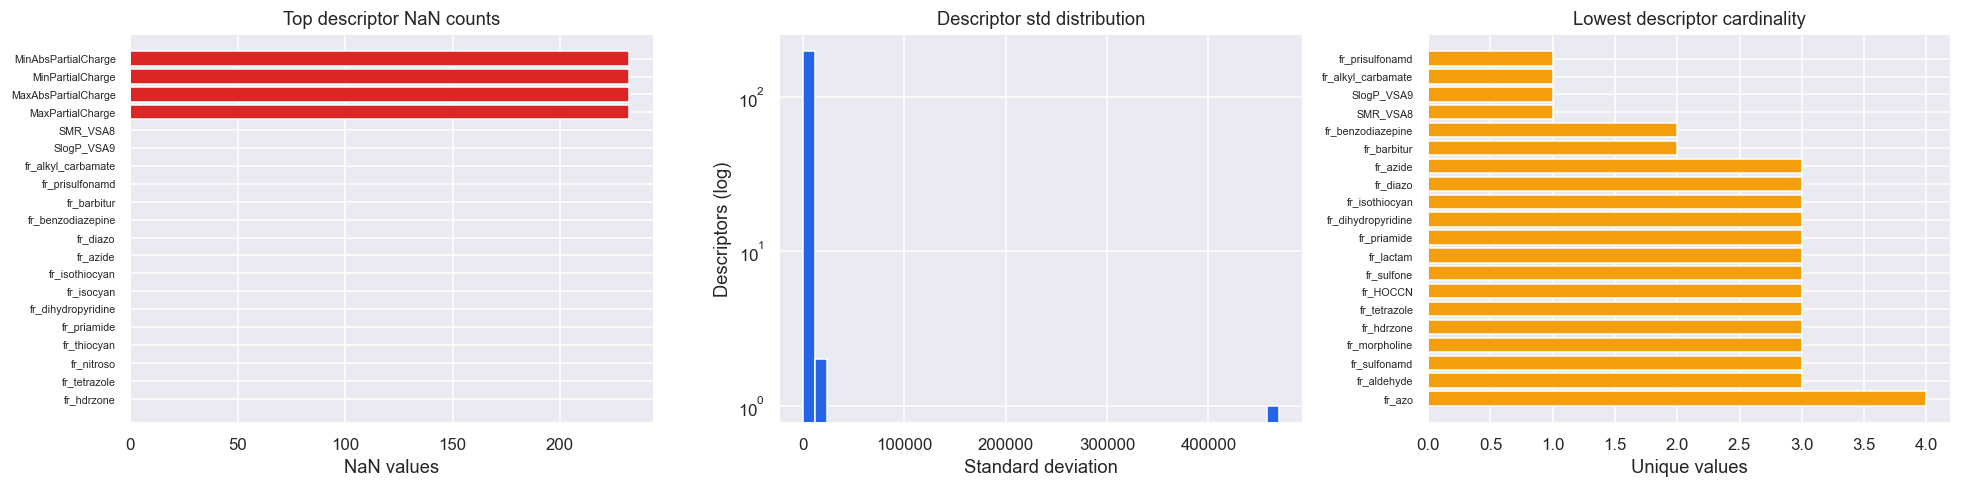

In [10]:
desc_validation = pd.DataFrame(
    {
        "missing": desc_df.isna().sum(),
        "missing_pct": desc_df.isna().mean() * 100,
        "std": desc_df.std(numeric_only=True),
        "n_unique": desc_df.nunique(dropna=True),
    }
).sort_values(["missing", "std"], ascending=[False, True])

constant_desc = desc_validation[desc_validation["n_unique"] <= 1]
high_missing_desc = desc_validation[desc_validation["missing_pct"] > 1]

print(f"Constant descriptors:        {len(constant_desc)}")
print(f"Descriptors with >1% NaN:    {len(high_missing_desc)}")
display(desc_validation.head(15).round(3))

fig, axes = plt.subplots(1, 3, figsize=(18, 4.6))

top_missing_desc = desc_validation.sort_values("missing", ascending=False).head(20)
axes[0].barh(range(len(top_missing_desc)), top_missing_desc["missing"], color="#dc2626")
axes[0].set_yticks(range(len(top_missing_desc)))
axes[0].set_yticklabels(top_missing_desc.index, fontsize=7)
axes[0].invert_yaxis()
axes[0].set_title("Top descriptor NaN counts")
axes[0].set_xlabel("NaN values")

desc_std = desc_validation["std"].replace([np.inf, -np.inf], np.nan).dropna()
axes[1].hist(desc_std, bins=40, color="#2563eb", edgecolor="white", log=True)
axes[1].set_title("Descriptor std distribution")
axes[1].set_xlabel("Standard deviation")
axes[1].set_ylabel("Descriptors (log)")

low_unique = desc_validation.sort_values("n_unique").head(20)
axes[2].barh(range(len(low_unique)), low_unique["n_unique"], color="#f59e0b")
axes[2].set_yticks(range(len(low_unique)))
axes[2].set_yticklabels(low_unique.index, fontsize=7)
axes[2].invert_yaxis()
axes[2].set_title("Lowest descriptor cardinality")
axes[2].set_xlabel("Unique values")

plt.tight_layout()
plt.show()


**Opis:** sprawdzam jakość deskryptorów RDKit2D. Widać, gdzie są braki, które cechy mocno się zmieniają i które prawie nic nie wnoszą.

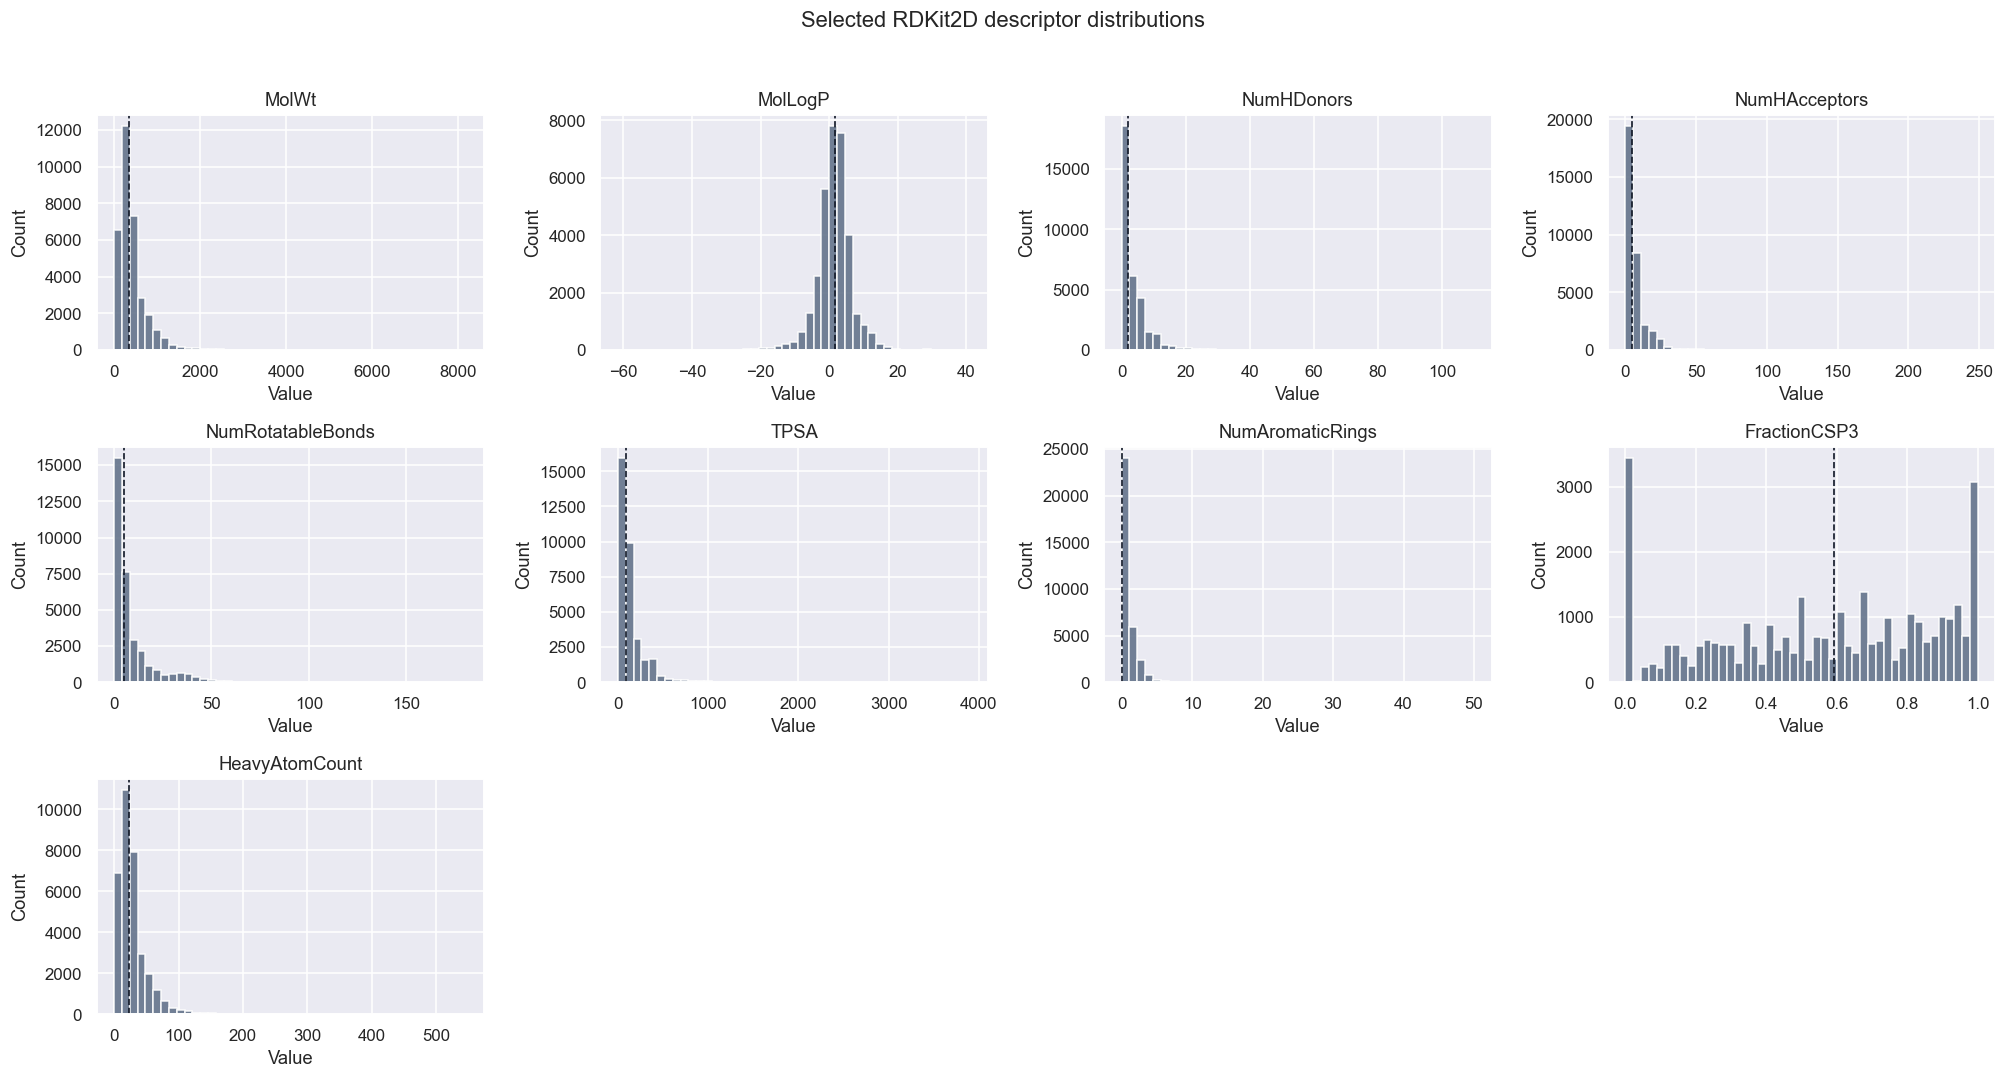

In [11]:
preferred = [
    "MolWt",
    "MolLogP",
    "NumHDonors",
    "NumHAcceptors",
    "NumRotatableBonds",
    "TPSA",
    "NumAromaticRings",
    "FractionCSP3",
    "HeavyAtomCount",
]
selected_desc = []
for col in preferred:
    if col in desc_df.columns:
        selected_desc.append(col)

if len(selected_desc) < 8:
    top_std = (
        desc_df.std(numeric_only=True)
        .sort_values(ascending=False)
        .head(8)
        .index.tolist()
    )
    for col in top_std:
        if col not in selected_desc:
            selected_desc.append(col)
    selected_desc = selected_desc[:8]

n_cols = min(4, max(1, len(selected_desc)))
n_rows = int(np.ceil(len(selected_desc) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.6 * n_cols, 3.2 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, selected_desc):
    data = desc_df[col].dropna()
    ax.hist(data, bins=45, color="#64748b", edgecolor="white", alpha=0.9)
    ax.axvline(data.median(), color="#111827", linestyle="--", linewidth=1.1)
    ax.set_title(col)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")

for ax in axes[len(selected_desc):]:
    ax.axis("off")

plt.suptitle("Selected RDKit2D descriptor distributions", y=1.02)
plt.tight_layout()
plt.show()


**Opis:** rozkłady kilku wybranych deskryptorów. Linie pokazują medianę, więc łatwo zobaczyć, czy wartości są skupione, rozciągnięte albo mają odstające przypadki.

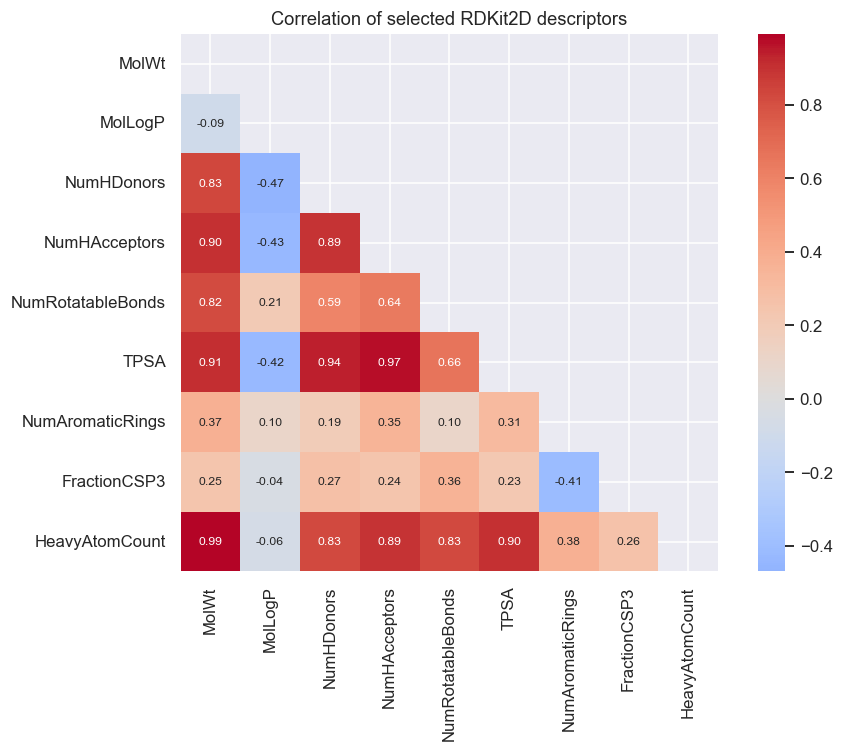

In [12]:
corr_cols = selected_desc[:10]
if len(corr_cols) >= 2:
    corr = desc_df[corr_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(
        corr,
        mask=mask,
        cmap="coolwarm",
        center=0,
        annot=True,
        fmt=".2f",
        square=True,
        ax=ax,
        annot_kws={"size": 8},
    )
    ax.set_title("Correlation of selected RDKit2D descriptors")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough descriptors selected for correlation heatmap.")


**Opis:** korelacje między deskryptorami. Pokazana jest tylko połowa macierzy, bo druga byłaby taka sama. Chodzi o sprawdzenie, które cechy mówią podobne rzeczy.

### Wnioski z deskryptorow RDKit2D

- Deskryptory RDKit2D sa interpretowalne chemicznie, wiec nadaja sie jako dobry baseline i material do opisu danych w sprawozdaniu.
- Przed modelem trzeba usunac albo zignorowac stale deskryptory, a brakujace wartosci uzupelnic mediana liczona tylko na zbiorze treningowym.
- Deskryptory numeryczne maja rozne skale, dlatego po imputacji warto je standaryzowac; fingerprintow binarnych nie nalezy skalowac w ten sam sposob.
- Silne korelacje miedzy deskryptorami sa normalne w chemii, np. masa, liczba atomow ciezkich i niektore indeksy strukturalne czesto niosa podobna informacje.

## 7. ECFP fingerprinty ze scikit-fingerprints
ECFP oznacza Extended-Connectivity Fingerprint. W praktyce jest to sposób kodowania lokalnych fragmentów cząsteczki, czyli otoczeń atomów. Jeśli dany fragment występuje w cząsteczce, odpowiedni bit fingerprintu może zostać ustawiony na 1.

ECFP shape:             (33668, 2048)
Mean active bits:       40.78
Median active bits:     38.0
Min / max active bits:  1 / 205
Unused bits:            0 / 2048
Bits active in >10%:    64
Fingerprint density:    0.01991


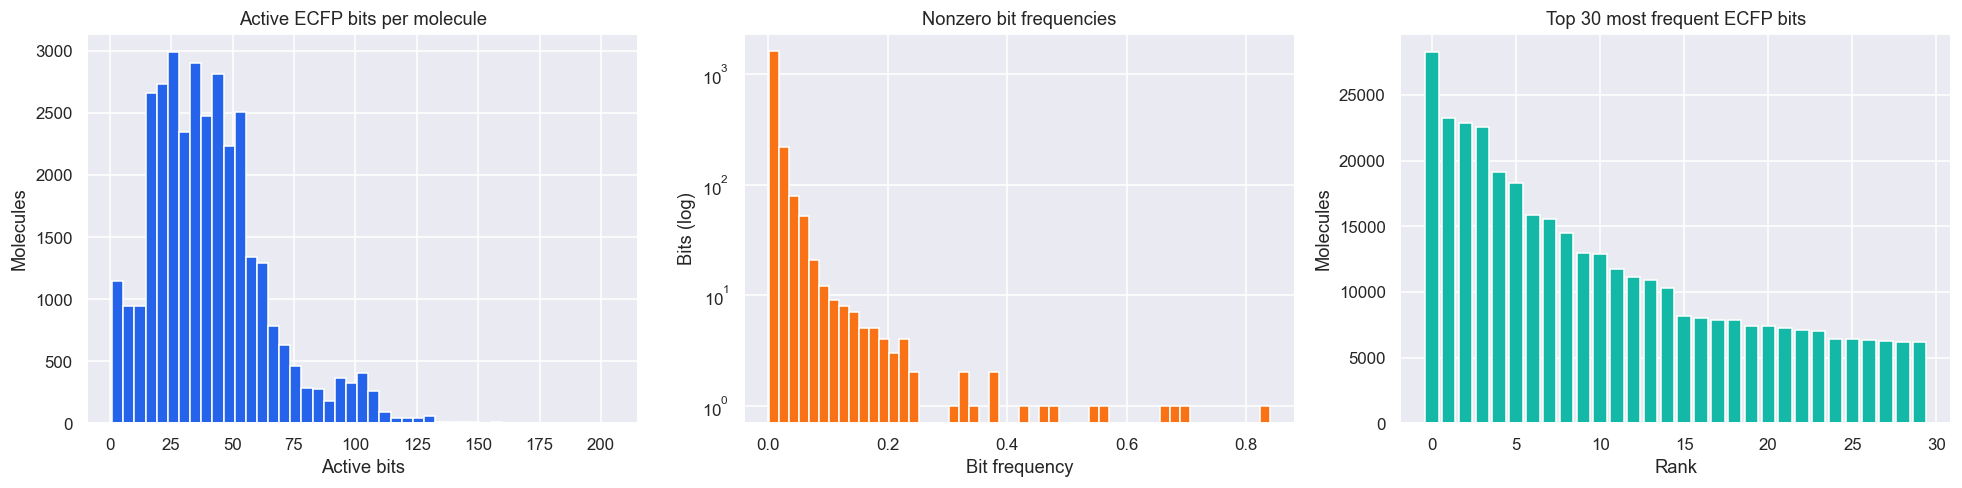

In [13]:
ECFP_SIZE = 2048

ecfp = ECFPFingerprint(
    fp_size=ECFP_SIZE,
    radius=2,
    include_chirality=True,
    sparse=True,
    n_jobs=-1,
)
X_ecfp = ecfp.transform(valid_df["canonical_smiles"].tolist())

bits_per_mol = np.asarray(X_ecfp.sum(axis=1)).ravel()
bit_counts = np.asarray(X_ecfp.sum(axis=0)).ravel()
bit_freq = bit_counts / X_ecfp.shape[0]

mean_active_bits = bits_per_mol.mean()
median_active_bits = np.median(bits_per_mol)
min_active_bits = bits_per_mol.min()
max_active_bits = bits_per_mol.max()
unused_ecfp_bits = int((bit_counts == 0).sum())
bits_active_over_10_pct = int((bit_freq > 0.10).sum())
fingerprint_density = bits_per_mol.sum() / np.prod(X_ecfp.shape)

print(f"ECFP shape:             {X_ecfp.shape}")
print(f"Mean active bits:       {mean_active_bits:.2f}")
print(f"Median active bits:     {median_active_bits:.1f}")
print(f"Min / max active bits:  {min_active_bits:.0f} / {max_active_bits:.0f}")
print(f"Unused bits:            {unused_ecfp_bits:,} / {ECFP_SIZE}")
print(f"Bits active in >10%:    {bits_active_over_10_pct:,}")
print(f"Fingerprint density:    {fingerprint_density:.5f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 4.6))

axes[0].hist(bits_per_mol, bins=45, color="#2563eb", edgecolor="white")
axes[0].set_title("Active ECFP bits per molecule")
axes[0].set_xlabel("Active bits")
axes[0].set_ylabel("Molecules")

axes[1].hist(bit_freq[bit_freq > 0], bins=50, color="#f97316", edgecolor="white", log=True)
axes[1].set_title("Nonzero bit frequencies")
axes[1].set_xlabel("Bit frequency")
axes[1].set_ylabel("Bits (log)")

top_bits = np.argsort(bit_counts)[-30:][::-1]
axes[2].bar(range(len(top_bits)), bit_counts[top_bits], color="#14b8a6")
axes[2].set_title("Top 30 most frequent ECFP bits")
axes[2].set_xlabel("Rank")
axes[2].set_ylabel("Molecules")

plt.tight_layout()
plt.show()


**Opis:** podstawowe statystyki fingerprintów ECFP. Widać, ile bitów aktywuje się dla cząsteczek i które bity pojawiają się najczęściej.

,check,status,value
0,Rows match valid molecules,OK,33668
1,Expected fingerprint width,OK,2048
2,No empty fingerprints,OK,0
3,No all-on bits,OK,0
4,Some unused bits are acceptable,OK,0


Active-bit outliers by IQR: 1,455


,SMILES,canonical_smiles,active_bits
5516,CC[C@H](C)[C@H](N=C(O)CN)C(O)=N[C@H](C(O)=N[C@...,CC[C@H](C)[C@H](N=C(O)CN)C(O)=N[C@H](C(O)=N[C@...,205
29562,C=C(N=C(O)[C@@H](N=C(O)[C@H](Cc1cnc[nH]1)N=C(O...,C=C(N=C(O)[C@@H](N=C(O)[C@H](Cc1cnc[nH]1)N=C(O...,195
9791,C=C(/C=C\C[C@@H](O)[C@@H](O)[C@H](O)C/C=C/C=C\...,C=C(/C=C\C[C@@H](O)[C@@H](O)[C@H](O)C/C=C/C=C\...,191
27031,CC[C@H](C)[C@H](N=C(O)[C@H](CCC(=O)O)N=C(O)[C@...,CC[C@H](C)[C@H](N=C(O)[C@H](CCC(=O)O)N=C(O)[C@...,190
16216,CC[C@H](C)[C@H](N=C(O)[C@H](CCC(=O)O)N=C(O)[C@...,CC[C@H](C)[C@H](N=C(O)[C@H](CCC(=O)O)N=C(O)[C@...,190
19416,CCCCCCCCCCCCCCCC(O)=N[C@@H](CCC([O-])=NCCOCCOC...,CCCCCCCCCCCCCCCC(O)=N[C@@H](CCC([O-])=NCCOCCOC...,187
10856,CCCCCCCCCCCCCCCC(O)=N[C@@H](CCC(O)=NCCOCCOCCOC...,CCCCCCCCCCCCCCCC(O)=N[C@@H](CCC(O)=NCCOCCOCCOC...,180
7171,CC(C)C[C@H](N=C(O)[C@@H](N)CC(=N)O)C(O)=N[C@@H...,CC(C)C[C@H](N=C(O)[C@@H](N)CC(=N)O)C(O)=N[C@@H...,166
17189,CCC(C)(C)[C@H](N=C(O)[C@H](N=C(O)[C@@H]1CCCN1C...,CCC(C)(C)[C@H](N=C(O)[C@H](N=C(O)[C@@H]1CCCN1C...,166
7009,CC(O)=N[C@@H]([C@H]1OC[C@H]2O[C@H](O[C@@H]3[C@...,CC(O)=N[C@@H]([C@H]1OC[C@H]2O[C@H](O[C@@H]3[C@...,163


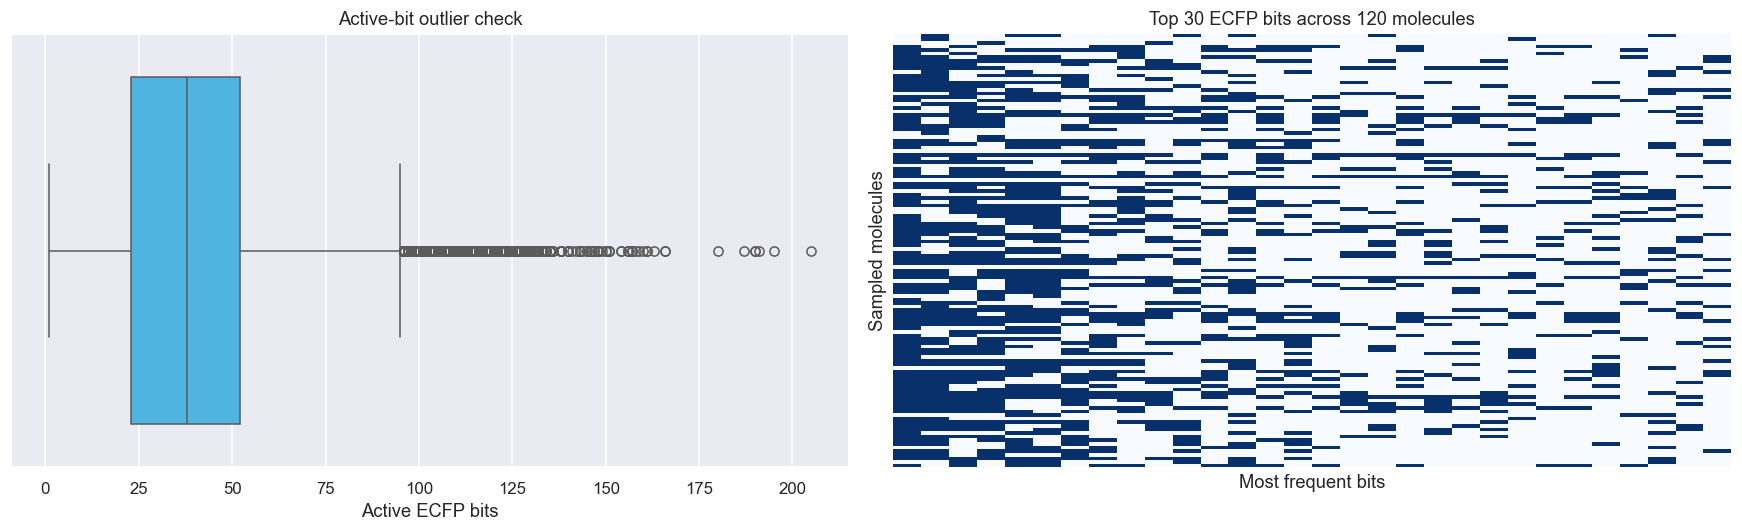

In [14]:
empty_fingerprints = int((bits_per_mol == 0).sum())
all_on_bits = int((bit_counts == X_ecfp.shape[0]).sum())

rows_match_status = "OK"
if X_ecfp.shape[0] != len(valid_df):
    rows_match_status = "FAIL"

width_status = "OK"
if X_ecfp.shape[1] != ECFP_SIZE:
    width_status = "FAIL"

empty_fp_status = "OK"
if empty_fingerprints != 0:
    empty_fp_status = "WARN"

all_on_status = "OK"
if all_on_bits != 0:
    all_on_status = "WARN"

unused_bits_status = "OK"
if unused_ecfp_bits >= X_ecfp.shape[1]:
    unused_bits_status = "FAIL"

fp_validation = pd.DataFrame(
    [
        {
            "check": "Rows match valid molecules",
            "status": rows_match_status,
            "value": X_ecfp.shape[0],
        },
        {
            "check": "Expected fingerprint width",
            "status": width_status,
            "value": X_ecfp.shape[1],
        },
        {
            "check": "No empty fingerprints",
            "status": empty_fp_status,
            "value": empty_fingerprints,
        },
        {
            "check": "No all-on bits",
            "status": all_on_status,
            "value": all_on_bits,
        },
        {
            "check": "Some unused bits are acceptable",
            "status": unused_bits_status,
            "value": unused_ecfp_bits,
        },
    ]
)
display(fp_validation)

active_q1, active_q3 = np.quantile(bits_per_mol, [0.25, 0.75])
active_iqr = active_q3 - active_q1
active_low = active_q1 - 1.5 * active_iqr
active_high = active_q3 + 1.5 * active_iqr
fp_outlier_mask = (bits_per_mol < active_low) | (bits_per_mol > active_high)
fp_outliers = valid_df.loc[fp_outlier_mask, [smiles_col, "canonical_smiles"]].copy()
fp_outliers["active_bits"] = bits_per_mol[fp_outlier_mask]

fp_outlier_count = len(fp_outliers)
print(f"Active-bit outliers by IQR: {fp_outlier_count:,}")
display(fp_outliers.sort_values("active_bits", ascending=False).head(12))

heatmap_rows = min(120, X_ecfp.shape[0])
heatmap_bits = min(64, len(top_bits))
heatmap_idx = rng.choice(X_ecfp.shape[0], size=heatmap_rows, replace=False)
bit_matrix = X_ecfp[heatmap_idx][:, top_bits[:heatmap_bits]].toarray()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(x=bits_per_mol, ax=axes[0], color="#38bdf8")
axes[0].set_title("Active-bit outlier check")
axes[0].set_xlabel("Active ECFP bits")

sns.heatmap(
    bit_matrix,
    cmap="Blues",
    cbar=False,
    xticklabels=False,
    yticklabels=False,
    ax=axes[1],
)
axes[1].set_title(f"Top {heatmap_bits} ECFP bits across {heatmap_rows} molecules")
axes[1].set_xlabel("Most frequent bits")
axes[1].set_ylabel("Sampled molecules")

plt.tight_layout()
plt.show()


**Opis:** kontrola nietypowych fingerprintów. Boxplot pokazuje cząsteczki z bardzo małą albo dużą liczbą aktywnych bitów, a heatmapa pokazuje przykładowe aktywacje bitów.

### Wnioski z walidacji ECFP

- ECFP jest reprezentacja rzadka i binarna; srednia liczba aktywnych bitow oraz gestosc fingerprintu sa podstawowymi metrykami kontroli jakosci.
- Puste fingerprinty albo bity aktywne dla wszystkich czasteczek bylyby sygnalem problemu z parsowaniem lub zbyt mala liczba bitow.
- Duza liczba nieuzywanych bitow nie musi byc bledem, ale przy bardzo malej gestosci mozna porownac mniejszy rozmiar fingerprintu albo inne parametry.
- Outliery aktywnych bitow warto obejrzec recznie, bo czesto odpowiadaja bardzo duzym, zlozonym albo nietypowo zapisanym czasteczkom.

## 8. Porownanie wariantow ECFP/FCFP

,fingerprint,mean_active_bits,median_active_bits,unused_bits,density
0,ECFP4,40.4270,38.0,0,0.0197
1,ECFP4 chiral,40.8914,38.0,0,0.0200
2,ECFP6 chiral,56.2254,52.0,0,0.0275
3,FCFP4 chiral,30.6270,29.0,19,0.0150


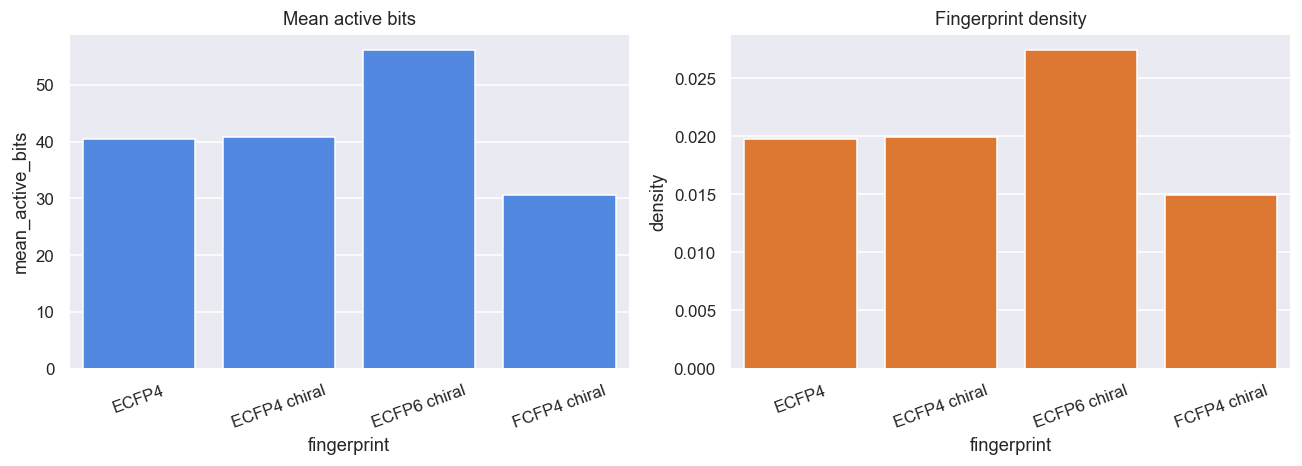

In [15]:
rng = np.random.default_rng(42)
variant_sample_size = min(5_000, len(valid_df))
variant_idx = rng.choice(len(valid_df), size=variant_sample_size, replace=False)
variant_smiles = valid_df["canonical_smiles"].iloc[variant_idx].tolist()

variant_fps = {
    "ECFP4": ECFPFingerprint(fp_size=2048, radius=2, include_chirality=False, sparse=True, n_jobs=-1),
    "ECFP4 chiral": ECFPFingerprint(fp_size=2048, radius=2, include_chirality=True, sparse=True, n_jobs=-1),
    "ECFP6 chiral": ECFPFingerprint(fp_size=2048, radius=3, include_chirality=True, sparse=True, n_jobs=-1),
    "FCFP4 chiral": ECFPFingerprint(
        fp_size=2048,
        radius=2,
        include_chirality=True,
        use_pharmacophoric_invariants=True,
        sparse=True,
        n_jobs=-1,
    ),
}

variant_rows = []
for name, fp in variant_fps.items():
    X_variant = fp.transform(variant_smiles)
    active = np.asarray(X_variant.sum(axis=1)).ravel()
    bit_counts_variant = np.asarray(X_variant.sum(axis=0)).ravel()
    variant_rows.append(
        {
            "fingerprint": name,
            "mean_active_bits": active.mean(),
            "median_active_bits": np.median(active),
            "unused_bits": int((bit_counts_variant == 0).sum()),
            "density": active.sum() / np.prod(X_variant.shape),
        }
    )

variant_df = pd.DataFrame(variant_rows)
display(variant_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
sns.barplot(data=variant_df, x="fingerprint", y="mean_active_bits", ax=axes[0], color="#3b82f6")
axes[0].set_title("Mean active bits")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=variant_df, x="fingerprint", y="density", ax=axes[1], color="#f97316")
axes[1].set_title("Fingerprint density")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


**Opis:** porównanie kilku wersji fingerprintów. Patrzę, ile bitów aktywują i jak gęste są te reprezentacje, żeby wybrać sensowny wariant do baseline'u.

### Wnioski z porownania fingerprintow

- ECFP4 jest dobrym ustawieniem startowym, bo zwykle lapie lokalne otoczenia atomow bez nadmiernego rozrzedzenia cech.
- Wariant z chiralnoscia jest bezpieczniejszy dla danych chemicznych, jezeli stereochemia moze zmieniac klase albo wlasciwosci zwiazku.
- ECFP6 zwykle aktywuje wiecej bitow i opisuje szerszy kontekst strukturalny, ale moze zwiekszac ryzyko kolizji albo szumu przy mniejszej liczbie danych.
- FCFP opisuje bardziej farmakoforowe cechy atomow; moze byc sensowny jako alternatywa, ale baseline warto zaczac od ECFP4 chiral.

## 9. Podobienstwo Tanimoto na próbce
Tanimoto to miara podobieństwa często używana dla fingerprintów chemicznych. W uproszczeniu sprawdza, ile aktywnych bitów dwie cząsteczki mają wspólnych w porównaniu do liczby bitów aktywnych w którejkolwiek z nich.



Sample size:             800
Mean Tanimoto:           0.0793
Median Tanimoto:         0.0698
95th percentile:         0.1818
Pairs with Tanimoto>.7:  219


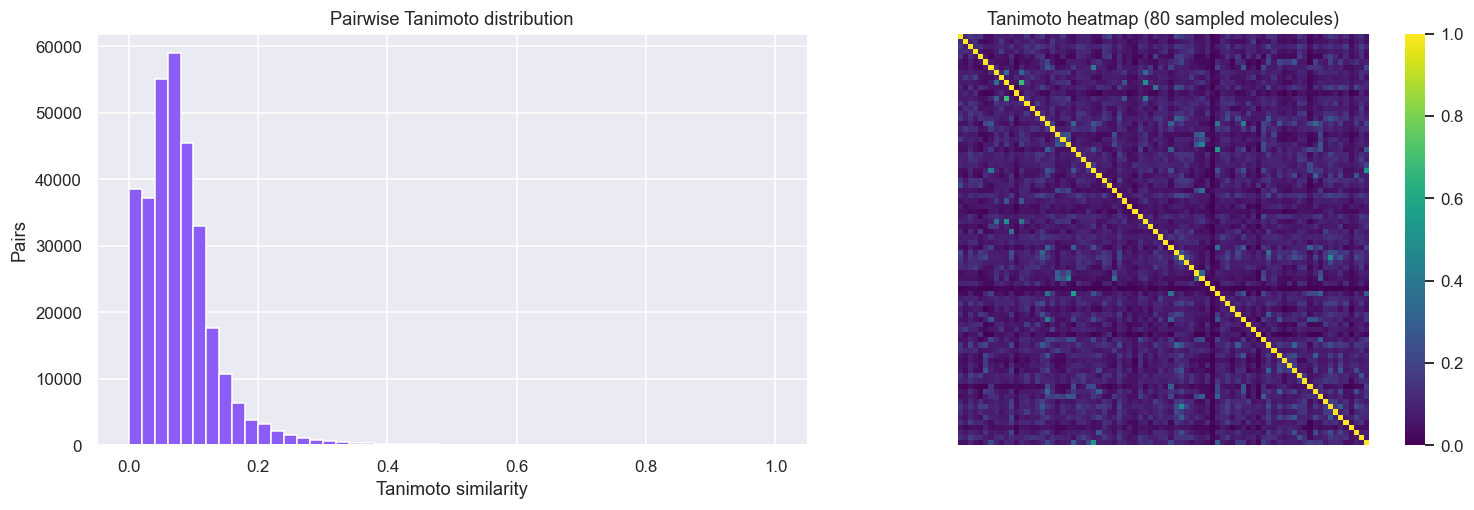

In [16]:
tanimoto_sample_size = min(800, X_ecfp.shape[0])
tanimoto_idx = rng.choice(X_ecfp.shape[0], size=tanimoto_sample_size, replace=False)
Xs = X_ecfp[tanimoto_idx].astype(np.float32)

intersection = Xs @ Xs.T
if hasattr(intersection, "toarray"):
    intersection = intersection.toarray()

sample_bit_sums = np.asarray(Xs.sum(axis=1)).ravel()
union = sample_bit_sums[:, None] + sample_bit_sums[None, :] - intersection
tanimoto = np.divide(
    intersection,
    union,
    out=np.zeros_like(intersection, dtype=float),
    where=union > 0,
)
tanimoto_values = tanimoto[np.triu_indices_from(tanimoto, k=1)]

mean_tanimoto = tanimoto_values.mean()
median_tanimoto = np.median(tanimoto_values)
tanimoto_95_percentile = np.quantile(tanimoto_values, 0.95)
pairs_over_07 = int((tanimoto_values > 0.7).sum())

print(f"Sample size:             {tanimoto_sample_size:,}")
print(f"Mean Tanimoto:           {mean_tanimoto:.4f}")
print(f"Median Tanimoto:         {median_tanimoto:.4f}")
print(f"95th percentile:         {tanimoto_95_percentile:.4f}")
print(f"Pairs with Tanimoto>.7:  {pairs_over_07:,}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].hist(tanimoto_values, bins=50, color="#8b5cf6", edgecolor="white")
axes[0].set_title("Pairwise Tanimoto distribution")
axes[0].set_xlabel("Tanimoto similarity")
axes[0].set_ylabel("Pairs")

heatmap_n = min(80, tanimoto_sample_size)
sns.heatmap(
    tanimoto[:heatmap_n, :heatmap_n],
    cmap="viridis",
    square=True,
    xticklabels=False,
    yticklabels=False,
    ax=axes[1],
)
axes[1].set_title(f"Tanimoto heatmap ({heatmap_n} sampled molecules)")

plt.tight_layout()
plt.show()


**Opis:** podobieństwo Tanimoto między cząsteczkami. Histogram pokazuje ogólny rozkład podobieństw, a heatmapa pokazuje podobieństwa w małej próbce.

Mean nearest-neighbor Tanimoto:   0.4425
Median nearest-neighbor Tanimoto: 0.3846
Nearest-neighbor > .85:           54


,tanimoto,row_i,row_j,smiles_i,smiles_j
752,1.0000,2401,21052,CCCCCC/C=C\CCCCCCCCCC(=O)O[C@H](COC(=O)CCCCCCC...,CCCCCCCC/C=C\CCCCCCCC(=O)O[C@H](COC(=O)CCCCCCC...
41,1.0000,17674,29248,CCCCCCCCCCCCCCC(O)CC,CCCCCCCCCCCCCCCCC(O)CC
17,1.0000,29060,4628,CCCCCCCCCC([O-])=N[C@@H](O)C(=O)O,CCCCCCCCCCCC([O-])=N[C@@H](O)C(=O)O
50,1.0000,3900,29848,CCCCCCCCCCCCCCCCC[C@@H](O)[C@H](CO)N=C(O)CCCCC...,CCCCCCCCCCCCCCCC(O)=N[C@@H](CO)[C@H](O)CCCCCCC...
389,1.0000,723,6853,N[C@H]1[C@@H](O[C@@H]2[C@H](O)[C@@H](N)[C@@H](...,N[C@H]1[C@@H](O[C@@H]2[C@H](O)[C@@H](N)[C@@H](...
89,1.0000,9019,32846,CCCCC/C=C\C/C=C\C/C=C\C/C=C\CCCC(=O)O[C@H](COC...,CCCCC/C=C\C/C=C\C/C=C\C/C=C\CCCC(=O)O[C@H](COC...
529,1.0000,6174,30548,CCCCCCCCCCCCC(O)CCCCCCCC,CCCCCCCCCCCCCCC(O)CCCCCCCC
270,1.0000,2401,553,CCCCCC/C=C\CCCCCCCCCC(=O)O[C@H](COC(=O)CCCCCCC...,CCCCCCCC/C=C\CCCCCCCCCC(=O)OC[C@H](COP(=O)([O-...
772,1.0000,9019,3254,CCCCC/C=C\C/C=C\C/C=C\C/C=C\CCCC(=O)O[C@H](COC...,CCCCC/C=C\C/C=C\C/C=C\C/C=C\CCCC(=O)O[C@H](COC...
474,0.9794,13139,26846,CCCCCCCCC=CCCCCCCCCCCCCCC(O)=N[C@@H](CO[C@@H]1...,CCCCCCCCCCCCC/C=C/[C@@H](O)[C@H](CO[C@@H]1O[C@...


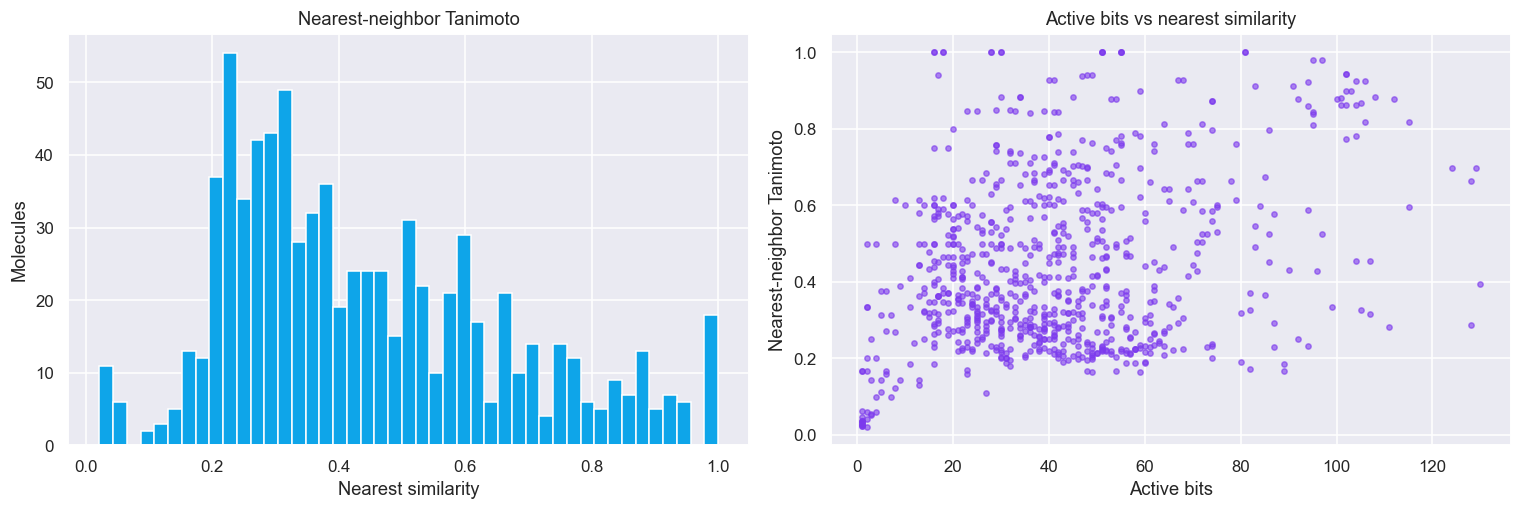

In [17]:
nearest = tanimoto.copy()
np.fill_diagonal(nearest, -1)
nearest_similarity = nearest.max(axis=1)
nearest_neighbor_pos = nearest.argmax(axis=1)

pair_candidates = []
for sample_pos, neighbor_pos in enumerate(nearest_neighbor_pos):
    i, j = sorted((sample_pos, int(neighbor_pos)))
    pair_candidates.append((float(tanimoto[i, j]), i, j))

top_pairs = (
    pd.DataFrame(pair_candidates, columns=["tanimoto", "sample_i", "sample_j"])
    .drop_duplicates(["sample_i", "sample_j"])
    .sort_values("tanimoto", ascending=False)
    .head(12)
)
row_i_values = []
row_j_values = []
smiles_i_values = []
smiles_j_values = []

for _, row in top_pairs.iterrows():
    sample_i = int(row["sample_i"])
    sample_j = int(row["sample_j"])

    row_i = valid_df.index[tanimoto_idx[sample_i]]
    row_j = valid_df.index[tanimoto_idx[sample_j]]
    row_i_values.append(row_i)
    row_j_values.append(row_j)

    smiles_i = valid_df.iloc[tanimoto_idx[sample_i]]["canonical_smiles"]
    smiles_j = valid_df.iloc[tanimoto_idx[sample_j]]["canonical_smiles"]
    smiles_i_values.append(smiles_i)
    smiles_j_values.append(smiles_j)

top_pairs["row_i"] = row_i_values
top_pairs["row_j"] = row_j_values
top_pairs["smiles_i"] = smiles_i_values
top_pairs["smiles_j"] = smiles_j_values

mean_nearest_similarity = nearest_similarity.mean()
median_nearest_similarity = np.median(nearest_similarity)
nearest_over_085 = int((nearest_similarity > 0.85).sum())

print(f"Mean nearest-neighbor Tanimoto:   {mean_nearest_similarity:.4f}")
print(f"Median nearest-neighbor Tanimoto: {median_nearest_similarity:.4f}")
print(f"Nearest-neighbor > .85:           {nearest_over_085:,}")
display(top_pairs[["tanimoto", "row_i", "row_j", "smiles_i", "smiles_j"]].round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].hist(nearest_similarity, bins=45, color="#0ea5e9", edgecolor="white")
axes[0].set_title("Nearest-neighbor Tanimoto")
axes[0].set_xlabel("Nearest similarity")
axes[0].set_ylabel("Molecules")

axes[1].scatter(
    sample_bit_sums,
    nearest_similarity,
    s=12,
    alpha=0.6,
    color="#7c3aed",
)
axes[1].set_title("Active bits vs nearest similarity")
axes[1].set_xlabel("Active bits")
axes[1].set_ylabel("Nearest-neighbor Tanimoto")

plt.tight_layout()
plt.show()


**Opis:** tutaj widać podobieństwo do najbliższego sąsiada. To pomaga sprawdzić, czy w danych są bardzo podobne cząsteczki, które mogłyby zawyżyć wynik modelu.

### Wnioski z podobienstwa Tanimoto

- Rozklad Tanimoto pokazuje, czy zbior zawiera wiele bardzo podobnych czasteczek; wysokie wartosci najblizszego sasiada moga wskazywac serie analogow lub prawie-duplikaty.
- Najbardziej podobne pary warto sprawdzic przed podzialem danych, bo podobne czasteczki w train i test moga zawyzac wynik modelu.
- Jezeli wiele par ma Tanimoto powyzej 0.85, warto rozwazyc scaffold split albo split po klastrach zamiast zwyklego losowego splitu.
- Niskie srednie podobienstwo globalne przy wysokich podobienstwach najblizszych sasiadow oznacza, ze dane sa roznorodne, ale lokalnie maja rodziny podobnych struktur.

## 10. Struktura fingerprintow: rzut SVD
SVD to metoda redukcji wymiarowości. Fingerprint ma 2048 bitów, więc jest trudny do pokazania na wykresie. SVD ściska te informacje do dwóch wymiarów, żeby dało się narysować punkty na płaszczyźnie.

Explained variance ratio: 0.0963


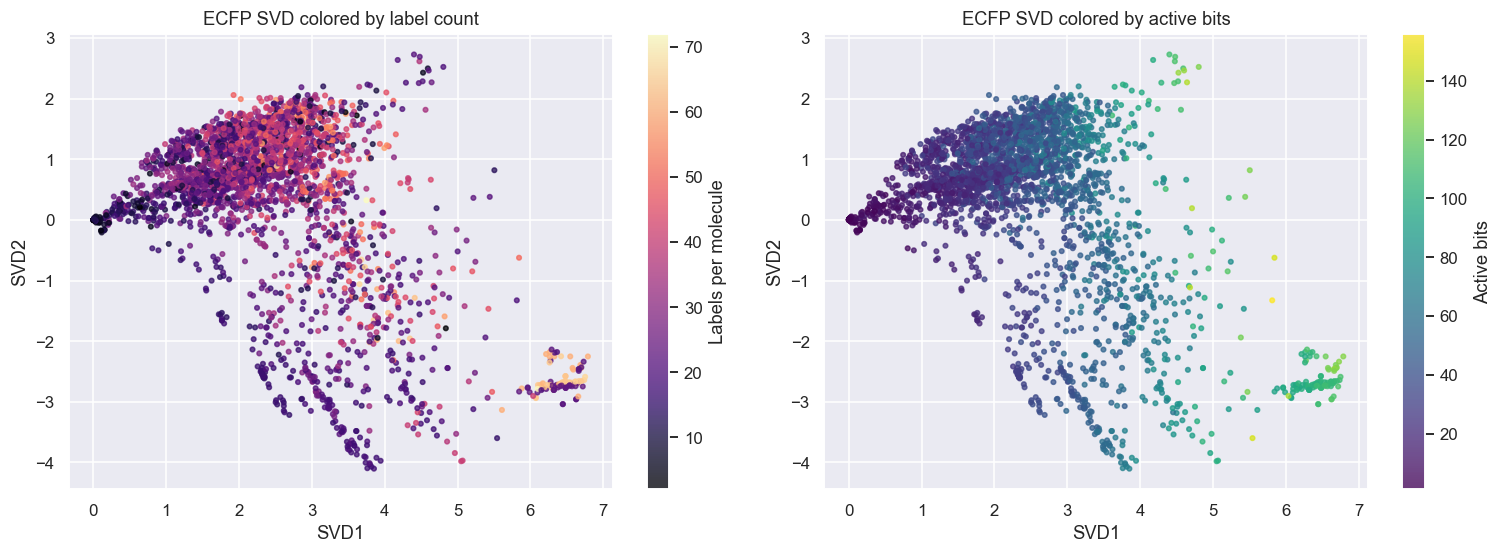

In [18]:
svd_sample_size = min(3_000, X_ecfp.shape[0])
svd_idx = rng.choice(X_ecfp.shape[0], size=svd_sample_size, replace=False)

svd = TruncatedSVD(n_components=2, random_state=42)
coords = svd.fit_transform(X_ecfp[svd_idx])

labels_arr = labels_per_mol.to_numpy()
plot_df = pd.DataFrame(
    {
        "SVD1": coords[:, 0],
        "SVD2": coords[:, 1],
        "labels_per_mol": labels_arr[svd_idx],
        "active_bits": bits_per_mol[svd_idx],
    }
)

explained_variance_2d = svd.explained_variance_ratio_.sum()
print(f"Explained variance ratio: {explained_variance_2d:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

sc0 = axes[0].scatter(
    plot_df["SVD1"],
    plot_df["SVD2"],
    c=plot_df["labels_per_mol"],
    cmap="magma",
    s=9,
    alpha=0.75,
)
axes[0].set_title("ECFP SVD colored by label count")
axes[0].set_xlabel("SVD1")
axes[0].set_ylabel("SVD2")
plt.colorbar(sc0, ax=axes[0], label="Labels per molecule")

sc1 = axes[1].scatter(
    plot_df["SVD1"],
    plot_df["SVD2"],
    c=plot_df["active_bits"],
    cmap="viridis",
    s=9,
    alpha=0.75,
)
axes[1].set_title("ECFP SVD colored by active bits")
axes[1].set_xlabel("SVD1")
axes[1].set_ylabel("SVD2")
plt.colorbar(sc1, ax=axes[1], label="Active bits")

plt.tight_layout()
plt.show()


**Opis:** rzut SVD fingerprintów do dwóch wymiarów. To nie jest dowód separacji klas, ale daje ogólny obraz, czy w danych widać jakieś skupiska.

### Wnioski z rzutu SVD

- Rzut SVD nie jest dowodem separowalnosci klas, ale pomaga zobaczyc, czy fingerprinty tworza widoczne skupiska strukturalne.
- Kolorowanie liczbą etykiet pokazuje, czy czasteczki wieloetykietowe skupiaja sie w okreslonych regionach przestrzeni cech.
- Kolorowanie liczba aktywnych bitow pomaga wykryc, czy jeden region mapy jest zdominowany przez wieksze albo bardziej zlozone czasteczki.
- Jezeli punkty sa mocno wymieszane, prosty model liniowy moze byc niewystarczajacy dla czesci klas, ale nadal jest dobrym baseline'em.

## 11. Relacja fingerprintow z etykietami

,active_bits,labels_per_mol,smiles_length
count,33668.00,33668.00,33668.00
mean,40.78,27.53,72.45
std,23.81,12.50,84.33
min,1.00,1.00,1.00
25%,23.00,19.00,29.00
50%,38.00,25.00,49.00
75%,52.00,36.00,88.00
max,205.00,78.00,1603.00


,active_bits,labels_per_mol,smiles_length
active_bits,1.000,0.363,0.647
labels_per_mol,0.363,1.000,0.034
smiles_length,0.647,0.034,1.000


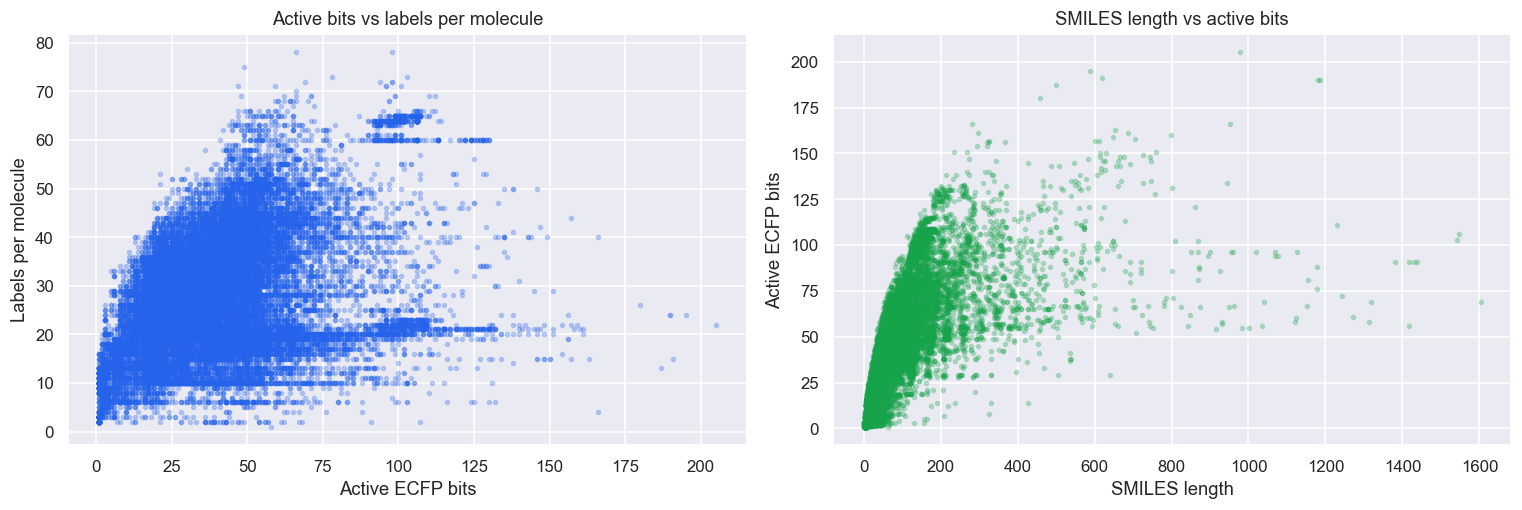

,class,n_pos,mean_active_bits_pos,mean_active_bits_neg,delta
1,class_1,33455,40.98,10.08,30.90
2,class_2,32795,41.41,17.33,24.08
5,class_5,30993,42.45,21.49,20.96
4,class_4,31057,42.37,21.92,20.45
3,class_3,32401,41.52,21.88,19.64
9,class_9,23406,43.07,35.58,7.49
8,class_8,24252,42.42,36.57,5.85
7,class_7,25025,42.01,37.23,4.78
6,class_6,27709,41.28,38.47,2.81
0,class_0,33668,40.78,NaN,NaN


In [19]:
fp_stats = pd.DataFrame(
    {
        "active_bits": bits_per_mol,
        "labels_per_mol": labels_per_mol.to_numpy(),
        "smiles_length": valid_df[smiles_col].astype(str).str.len().to_numpy(),
    },
    index=valid_df.index,
)

display(fp_stats.describe().round(2))
display(fp_stats.corr().round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

axes[0].scatter(
    fp_stats["active_bits"],
    fp_stats["labels_per_mol"],
    s=7,
    alpha=0.25,
    color="#2563eb",
)
axes[0].set_title("Active bits vs labels per molecule")
axes[0].set_xlabel("Active ECFP bits")
axes[0].set_ylabel("Labels per molecule")

axes[1].scatter(
    fp_stats["smiles_length"],
    fp_stats["active_bits"],
    s=7,
    alpha=0.25,
    color="#16a34a",
)
axes[1].set_title("SMILES length vs active bits")
axes[1].set_xlabel("SMILES length")
axes[1].set_ylabel("Active ECFP bits")

plt.tight_layout()
plt.show()

top_classes = class_freq.head(10).index.tolist()
class_rows = []
for cls in top_classes:
    pos = fp_stats.loc[label_df[cls].to_numpy().astype(bool), "active_bits"]
    neg = fp_stats.loc[~label_df[cls].to_numpy().astype(bool), "active_bits"]
    class_rows.append(
        {
            "class": cls,
            "n_pos": int(label_df[cls].sum()),
            "mean_active_bits_pos": pos.mean(),
            "mean_active_bits_neg": neg.mean(),
            "delta": pos.mean() - neg.mean(),
        }
    )

class_fp_summary = pd.DataFrame(class_rows).sort_values("delta", ascending=False)
display(class_fp_summary.round(2))


**Opis:** sprawdzam, czy liczba aktywnych bitów ma związek z liczbą etykiet i długością SMILES. To pomaga ocenić, czy większe cząsteczki są też bardziej opisane etykietami.

### Wnioski z relacji fingerprintow i etykiet

- Zaleznosc miedzy liczba aktywnych bitow a liczba etykiet pomaga sprawdzic, czy bardziej zlozone czasteczki sa czesciej opisywane wieloma klasami.
- Jezeli roznice `mean_active_bits_pos` vs `mean_active_bits_neg` sa duze dla wybranych klas, to sama zlozonosc struktury moze byc silnym sygnalem predykcyjnym.
- Dla klas, w ktorych roznice sa male, potrzebne beda bardziej subtelne cechy niz prosta liczba aktywnych bitow.
- Ta sekcja nie sluzy do wyboru modelu sama w sobie, ale pomaga wyjasnic, czy fingerprinty niosa sygnal powiazany z etykietami.

## 12. Co-occurrence etykiet

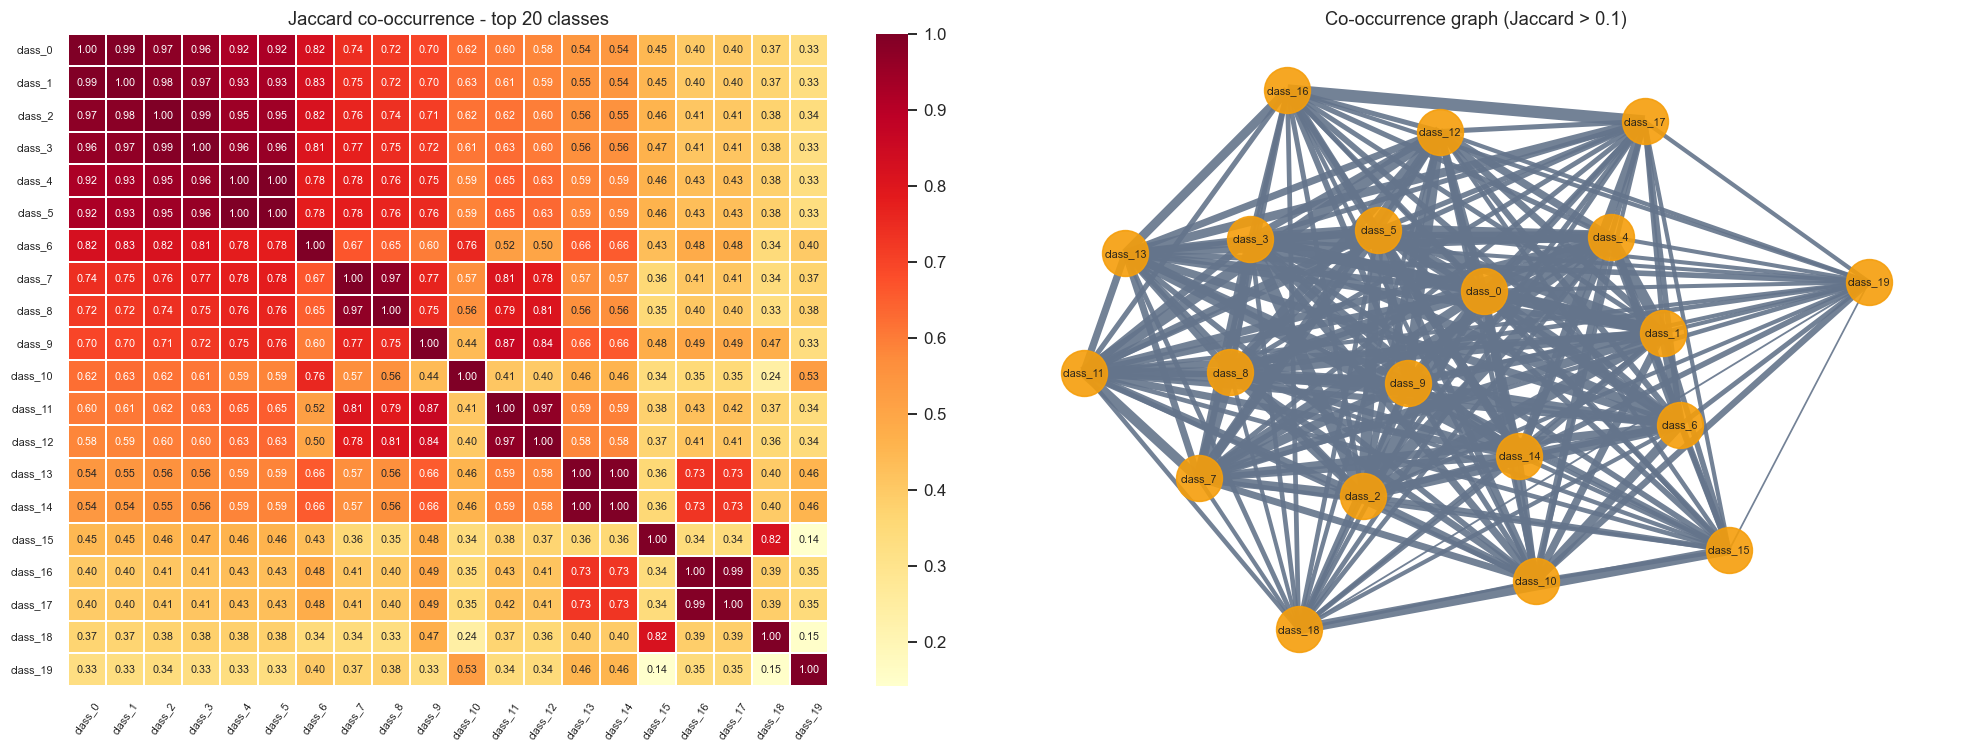

In [20]:
top20 = class_freq.head(20).index.tolist()
sub = label_df[top20].to_numpy(dtype=float)
cooc = sub.T @ sub

diag = np.diag(cooc)
union = diag[:, None] + diag[None, :] - cooc
jaccard = np.divide(cooc, union, out=np.zeros_like(cooc), where=union > 0)

short_labels = []
for label in top20:
    short_labels.append(label[:14])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(
    jaccard,
    xticklabels=short_labels,
    yticklabels=short_labels,
    cmap="YlOrRd",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7},
    linewidths=0.3,
    ax=axes[0],
)
axes[0].set_title("Jaccard co-occurrence - top 20 classes")
axes[0].tick_params(axis="x", rotation=55, labelsize=7)
axes[0].tick_params(axis="y", rotation=0, labelsize=7)

threshold = 0.10
G = nx.Graph()
for i, ci in enumerate(top20):
    for j, cj in enumerate(top20):
        if i < j and jaccard[i, j] > threshold:
            G.add_edge(ci[:14], cj[:14], weight=jaccard[i, j])

if G.number_of_edges() > 0:
    pos = nx.spring_layout(G, seed=42, k=1.8)
    weights = []
    for u, v in G.edges():
        weights.append(G[u][v]["weight"] * 8)
    nx.draw_networkx(
        G,
        pos,
        ax=axes[1],
        with_labels=True,
        node_color="#f59e0b",
        node_size=900,
        font_size=7,
        edge_color="#64748b",
        width=weights,
        alpha=0.9,
    )
    axes[1].set_title(f"Co-occurrence graph (Jaccard > {threshold})")
else:
    axes[1].text(0.5, 0.5, "No edges above threshold", ha="center", va="center")
    axes[1].set_title(f"Co-occurrence graph (Jaccard > {threshold})")
axes[1].axis("off")

plt.tight_layout()
plt.show()


**Opis:** współwystępowanie etykiet. Heatmapa pokazuje, które klasy często pojawiają się razem, a graf pokazuje te silniejsze powiązania jako połączenia.

### Wnioski z co-occurrence etykiet

- Etykiety nie sa niezalezne: macierz Jaccarda i graf wspolwystepowania pokazuja, ktore klasy czesto pojawiaja sie razem.
- Silne grupy wspolwystepowania moga ulatwic modelowi predykcje popularnych kombinacji, ale moga tez powodowac mylenie klas podobnych semantycznie.
- Jezeli graf ma wyrazne komponenty, mozna rozwazyc modele wykorzystujace zaleznosci miedzy etykietami albo progowanie predykcji osobno dla klas.

## 13. Hierarchia klas ChEBI

Plik `data/chebi_classes.obo` opisuje ontologie klas uzytych w etykietach. W tej sekcji sprawdzamy, czy klasy `class_0` ... `class_499` maja relacje `is_a`, jak wyglada struktura rodzic-dziecko oraz czy etykiety sa spojne z hierarchia.

,metric,value
0,ontology_terms,500
1,labels_in_dataset,500
2,labels_found_in_ontology,500
3,labels_missing_in_ontology,0
4,extra_ontology_terms,0
5,direct_is_a_edges_between_labels,748
6,root_classes,1
7,leaf_classes,188
8,is_dag,True
9,max_depth,14


,class,name,samples,n_direct_parents,depth
0,class_0,chemical entity,33668,0,0
1,class_1,molecular entity,33455,1,1
112,class_2,main group molecular entity,32795,1,2
223,class_3,p-block molecular entity,32401,1,3
334,class_4,carbon group molecular entity,31057,1,4
445,class_5,organic molecular entity,30993,1,5
456,class_6,polyatomic entity,27709,1,2
467,class_7,chalcogen molecular entity,25025,1,4
478,class_8,oxygen molecular entity,24252,1,5
489,class_9,heteroorganic entity,23406,1,6


No direct child-parent hierarchy violations found in label matrix.


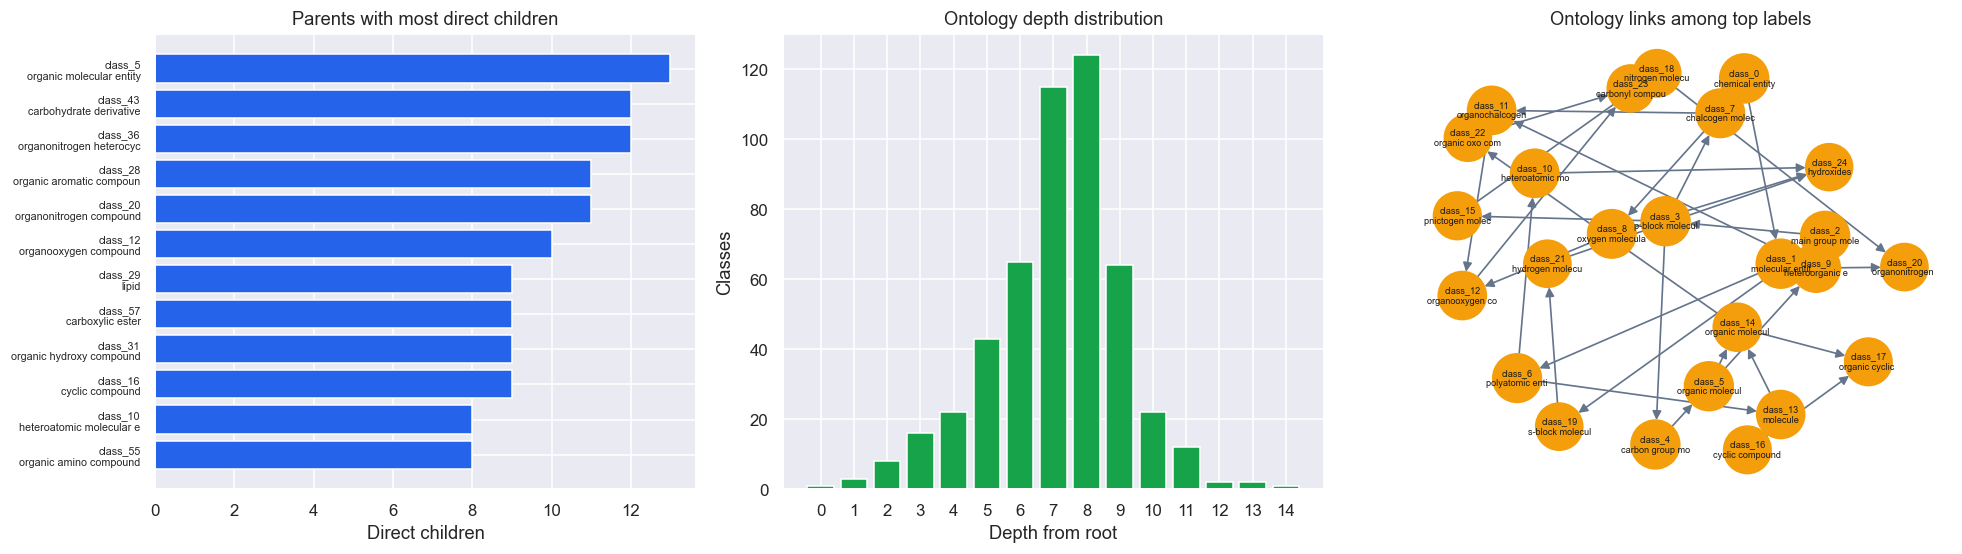

In [21]:
OBO_PATH = "data/chebi_classes.obo"


def parse_obo_terms(path):
    terms = []
    current = None

    with open(path, encoding="utf-8") as handle:
        for raw_line in handle:
            line = raw_line.strip()

            if line == "[Term]":
                if current and current.get("id"):
                    terms.append(current)
                current = {"parents": []}
                continue

            if current is None or not line:
                continue

            if line.startswith("id: "):
                current["id"] = line.removeprefix("id: ").strip()
            elif line.startswith("name: "):
                current["name"] = line.removeprefix("name: ").strip()
            elif line.startswith("is_a: "):
                parent = line.removeprefix("is_a: ").split()[0].strip()
                current["parents"].append(parent)

    if current and current.get("id"):
        terms.append(current)

    return terms


obo_terms = parse_obo_terms(OBO_PATH)

term_by_id = {}
for term in obo_terms:
    if "id" in term:
        term_by_id[term["id"]] = term

label_id_set = set(label_cols)

metadata_rows = []
for term_id, term in term_by_id.items():
    metadata_rows.append(
        {
            "class": term_id,
            "name": term.get("name", ""),
            "n_direct_parents": len(term.get("parents", [])),
        }
    )

class_metadata = pd.DataFrame(
    metadata_rows,
    columns=["class", "name", "n_direct_parents"],
)
class_metadata_in_data = class_metadata[class_metadata["class"].isin(label_id_set)].copy()
class_metadata_in_data["samples"] = (
    class_metadata_in_data["class"].map(class_freq).fillna(0).astype(int)
)

edge_rows = []
for child, term in term_by_id.items():
    if child not in label_id_set:
        continue
    for parent in term.get("parents", []):
        if parent in label_id_set:
            edge_rows.append(
                {
                    "child": child,
                    "child_name": term.get("name", ""),
                    "parent": parent,
                    "parent_name": term_by_id.get(parent, {}).get("name", ""),
                }
            )

hierarchy_edges_df = pd.DataFrame(
    edge_rows,
    columns=["child", "child_name", "parent", "parent_name"],
)

hierarchy_graph = nx.DiGraph()
hierarchy_graph.add_nodes_from(label_cols)
if not hierarchy_edges_df.empty:
    hierarchy_graph.add_edges_from(
        hierarchy_edges_df[["parent", "child"]].itertuples(index=False, name=None)
    )

is_hierarchy_dag = nx.is_directed_acyclic_graph(hierarchy_graph)

root_classes = []
leaf_classes = []
for node in hierarchy_graph.nodes:
    if hierarchy_graph.in_degree(node) == 0:
        root_classes.append(node)
    if hierarchy_graph.out_degree(node) == 0:
        leaf_classes.append(node)

if is_hierarchy_dag:
    depths = {}
    for node in hierarchy_graph.nodes:
        depths[node] = 0

    for root in root_classes:
        path_lengths = nx.single_source_shortest_path_length(hierarchy_graph, root)
        for node, distance in path_lengths.items():
            depths[node] = max(depths[node], distance)
else:
    depths = {}
    for node in hierarchy_graph.nodes:
        depths[node] = np.nan

depth_series = pd.Series(depths, name="depth")
class_metadata_in_data["depth"] = class_metadata_in_data["class"].map(depth_series)

missing_ontology_labels = sorted(label_id_set.difference(term_by_id))
extra_ontology_terms = sorted(set(term_by_id).difference(label_id_set))

violation_rows = []
total_direct_child_positives = 0
for row in hierarchy_edges_df.itertuples(index=False):
    child_active = label_df[row.child].to_numpy(dtype=bool)
    parent_inactive = ~label_df[row.parent].to_numpy(dtype=bool)
    direct_child_positives = int(child_active.sum())
    violations = int((child_active & parent_inactive).sum())
    total_direct_child_positives += direct_child_positives

    if violations:
        violation_rows.append(
            {
                "child": row.child,
                "child_name": row.child_name,
                "parent": row.parent,
                "parent_name": row.parent_name,
                "violations": violations,
                "child_positives": direct_child_positives,
                "violation_pct": violations / max(direct_child_positives, 1) * 100,
            }
        )

hierarchy_violation_df = pd.DataFrame(
    violation_rows,
    columns=[
        "child",
        "child_name",
        "parent",
        "parent_name",
        "violations",
        "child_positives",
        "violation_pct",
    ],
)
total_direct_violations = (
    int(hierarchy_violation_df["violations"].sum()) if len(hierarchy_violation_df) else 0
)

hierarchy_summary = pd.DataFrame(
    [
        {"metric": "ontology_terms", "value": len(term_by_id)},
        {"metric": "labels_in_dataset", "value": len(label_cols)},
        {"metric": "labels_found_in_ontology", "value": len(class_metadata_in_data)},
        {"metric": "labels_missing_in_ontology", "value": len(missing_ontology_labels)},
        {"metric": "extra_ontology_terms", "value": len(extra_ontology_terms)},
        {"metric": "direct_is_a_edges_between_labels", "value": len(hierarchy_edges_df)},
        {"metric": "root_classes", "value": len(root_classes)},
        {"metric": "leaf_classes", "value": len(leaf_classes)},
        {"metric": "is_dag", "value": bool(is_hierarchy_dag)},
        {
            "metric": "max_depth",
            "value": int(np.nanmax(depth_series.to_numpy())) if len(depth_series) else 0,
        },
        {"metric": "direct_child_parent_violations", "value": total_direct_violations},
        {"metric": "direct_child_positive_cases", "value": total_direct_child_positives},
    ]
)

display(hierarchy_summary)

top_hierarchy_labels = (
    class_metadata_in_data[["class", "name", "samples", "n_direct_parents", "depth"]]
    .sort_values("samples", ascending=False)
    .head(15)
)
display(top_hierarchy_labels)

if len(hierarchy_violation_df):
    display(
        hierarchy_violation_df
        .sort_values("violations", ascending=False)
        .head(15)
        .round({"violation_pct": 3})
    )
else:
    print("No direct child-parent hierarchy violations found in label matrix.")

fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))

if len(hierarchy_edges_df):
    parent_counts = hierarchy_edges_df["parent"].value_counts().head(12)

    parent_labels = []
    for cls in parent_counts.index:
        parent_name = term_by_id.get(cls, {}).get("name", "")
        parent_labels.append(f"{cls}\n{parent_name[:24]}")

    axes[0].barh(range(len(parent_counts)), parent_counts.values, color="#2563eb")
    axes[0].set_yticks(range(len(parent_counts)))
    axes[0].set_yticklabels(parent_labels, fontsize=7)
    axes[0].invert_yaxis()
    axes[0].set_title("Parents with most direct children")
    axes[0].set_xlabel("Direct children")
else:
    axes[0].text(0.5, 0.5, "No ontology edges", ha="center", va="center")
    axes[0].set_axis_off()

depth_counts = depth_series.dropna().astype(int).value_counts().sort_index()
axes[1].bar(depth_counts.index.astype(str), depth_counts.values, color="#16a34a")
axes[1].set_title("Ontology depth distribution")
axes[1].set_xlabel("Depth from root")
axes[1].set_ylabel("Classes")

top_graph_classes = set(class_freq.head(25).index)
H = nx.DiGraph()
for row in hierarchy_edges_df.itertuples(index=False):
    if row.parent in top_graph_classes and row.child in top_graph_classes:
        H.add_edge(row.parent, row.child)

if H.number_of_edges() > 0:
    pos = nx.spring_layout(H, seed=42, k=1.3)

    node_sizes = []
    node_labels = {}
    for node in H.nodes:
        node_size = 350 + np.log1p(class_freq.get(node, 0)) * 65
        node_sizes.append(node_size)

        node_name = term_by_id.get(node, {}).get("name", "")
        node_labels[node] = f"{node}\n{node_name[:15]}"

    nx.draw_networkx(
        H,
        pos,
        labels=node_labels,
        ax=axes[2],
        node_color="#f59e0b",
        node_size=node_sizes,
        edge_color="#64748b",
        arrows=True,
        arrowsize=12,
        font_size=6,
        width=1.1,
    )
    axes[2].set_title("Ontology links among top labels")
else:
    axes[2].text(
        0.5,
        0.5,
        "No direct is_a edges among top labels",
        ha="center",
        va="center",
    )
    axes[2].set_title("Ontology links among top labels")
axes[2].axis("off")

plt.tight_layout()
plt.show()


**Opis:** hierarchia klas ChEBI. Wykresy pokazują klasy nadrzędne, głębokość klas i relacje `is_a`; najważniejsze jest to, że nie ma naruszeń dziecko-rodzic.

### Wnioski z hierarchii klas ChEBI

- Ontologia `chebi_classes.obo` laczy etykiety relacjami `is_a`, czyli dziecko -> rodzic; to inny typ informacji niz statystyczne wspolwystepowanie etykiet.
- Zgodnosc macierzy etykiet z hierarchia mozna sprawdzic przez przypadki, w ktorych klasa dziecko ma wartosc 1, a jej bezposredni rodzic ma 0.
- Jezeli `direct_child_parent_violations` wynosi 0, etykiety sa poprawnie propagowane w gore bezposredniej hierarchii.


## 14. Podsumowanie

In [22]:
summary_rows = len(df)
summary_valid_smiles = len(valid_df)
summary_invalid_smiles = invalid_count
summary_unique_molecules = canon_counts.size
summary_duplicate_rows = duplicate_rows
summary_label_count = len(label_cols)
summary_rdkit2d_count = desc_df.shape[1]
summary_ecfp_size = X_ecfp.shape[1]
summary_mean_active_bits = bits_per_mol.mean()
summary_unused_bits = int((bit_counts == 0).sum())
summary_mean_tanimoto = tanimoto_values.mean()
summary_nn_tanimoto_median = np.median(nearest_similarity)
summary_duplicate_conflicts = len(duplicate_conflicts_df)
summary_descriptor_nan = int(nan_counts.sum())
summary_ontology_terms = len(class_metadata_in_data)
summary_ontology_edges = len(hierarchy_edges_df)
summary_hierarchy_violations = total_direct_violations

print("=" * 64)
print("EDA summary - ChEBI with scikit-fingerprints")
print("=" * 64)
print(f"Rows:                         {summary_rows:>10,}")
print(f"Valid SMILES:                 {summary_valid_smiles:>10,}")
print(f"Invalid/missing SMILES:       {summary_invalid_smiles:>10,}")
print(f"Unique canonical molecules:   {summary_unique_molecules:>10,}")
print(f"Duplicate rows:               {summary_duplicate_rows:>10,}")
print(f"Labels/classes:               {summary_label_count:>10,}")
print(f"Label cardinality:            {label_cardinality:>10.3f}")
print(f"Label density:                {label_density:>10.6f}")
print(f"Classes with 0 samples:       {classes_with_0_samples:>10,}")
print(f"Classes with 1 sample:        {classes_with_1_sample:>10,}")
print(f"RDKit2D descriptors:          {summary_rdkit2d_count:>10,}")
print(f"ECFP size:                    {summary_ecfp_size:>10,}")
print(f"Mean active ECFP bits:        {summary_mean_active_bits:>10.2f}")
print(f"Unused ECFP bits:             {summary_unused_bits:>10,}")
print(f"Mean Tanimoto sample:         {summary_mean_tanimoto:>10.4f}")
print(f"NN Tanimoto median:           {summary_nn_tanimoto_median:>10.4f}")
print(f"Duplicate label conflicts:    {summary_duplicate_conflicts:>10,}")
print(f"Descriptor NaN values:        {summary_descriptor_nan:>10,}")
print(f"Ontology terms in data:       {summary_ontology_terms:>10,}")
print(f"Direct ontology is_a edges:   {summary_ontology_edges:>10,}")
print(f"Hierarchy violations:         {summary_hierarchy_violations:>10,}")
print("=" * 64)
print()
print("Main takeaways:")
print("- Dataset is multilabel and strongly imbalanced.")
print("- Canonical SMILES should be used before duplicate checks or splits.")
print("- ECFP fingerprints are sparse; density and active-bit counts are useful QC metrics.")
print("- RDKit2D descriptors from skfp may contain NaN/inf, so imputation is needed before modeling.")
print("- Similarity and SVD plots help spot clusters, near-duplicates, and unusual molecules.")
print("- OBO hierarchy checks whether child labels are consistent with parent labels.")


EDA summary - ChEBI with scikit-fingerprints
Rows:                             33,668
Valid SMILES:                     33,668
Invalid/missing SMILES:                0
Unique canonical molecules:       33,632
Duplicate rows:                       36
Labels/classes:                      500
Label cardinality:                27.525
Label density:                  0.055051
Classes with 0 samples:                0
Classes with 1 sample:                 0
RDKit2D descriptors:                 200
ECFP size:                         2,048
Mean active ECFP bits:             40.78
Unused ECFP bits:                      0
Mean Tanimoto sample:             0.0793
NN Tanimoto median:               0.3846
Duplicate label conflicts:             7
Descriptor NaN values:               928
Ontology terms in data:              500
Direct ontology is_a edges:          748
Hierarchy violations:                  0

Main takeaways:
- Dataset is multilabel and strongly imbalanced.
- Canonical SMILES should be

### Wnioski koncowe i rekomendacje

1. Najpierw nalezy walidowac SMILES, zapisac `canonical_smiles`, usunac niepoprawne rekordy i scalic duplikaty operacja OR na etykietach.
2. Podzial na train/validation/test powinien powstac po kanonikalizacji i deduplikacji; przy wielu podobnych czasteczkach lepszy bedzie scaffold split albo split klastrowy.
3. Dla baseline'u warto przygotowac dwa zestawy cech: skalowane deskryptory RDKit2D oraz binarne ECFP4 chiral 2048 bitow.
4. Rzadkie klasy trzeba potraktowac jawnie: albo filtrowac klasy ponizej progu przykladow, albo raportowac metryki odporne na long-tail, np. macro F1 i PR-AUC.
5. Deskryptory numeryczne wymagaja imputacji i skalowania, ale fingerprinty binarne powinny zostac w postaci 0/1.
6. Najwazniejsze ryzyka dla modelu to class imbalance, podobne czasteczki w roznych splitach, konflikty etykiet w duplikatach oraz zbyt optymistyczna metryka accuracy.
7. Hierarchie ChEBI warto wykorzystac jako dodatkowy sanity check: predykcja klasy szczegolowej powinna byc spojna z predykcja jej klasy nadrzednej.